# 3D Autoencoder Architecture Optimization Experiments

This notebook runs experiments to optimize the 3D autoencoder architecture for brain MRI reconstruction. We'll implement and evaluate several optimization strategies:

1. **Direct strided convolution start**: Begin with a strided convolution (1->4) instead of an initial non-strided layer
2. **Channel reduction blocks**: Add 1x1 convolutions at the end of each block to reduce channels
3. **Grouped convolution bottleneck**: Implement specialized bottleneck architecture

We'll track and compare:
- Model parameter count
- Training and validation MSE
- Training time
- Memory usage
- Reconstruction quality

## 1. Setup and Imports

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time
import gc
import nibabel as nib
from IPython.display import display, HTML

# Add project root to path if needed
if not any(os.path.abspath(p) == os.path.abspath(os.getcwd()) for p in sys.path):
    sys.path.append(os.path.abspath(os.getcwd()))

# Import project modules
from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.model_variants import get_model_variant
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig
from models.autoencoder.direct_ae import ConvBlock, DirectAutoencoder
from models.autoencoder.optimized_ae import OptimizedConvBlock, ChannelReductionBlock, GroupedConvAutoencoder, OptimizedEncoder, LatentSpaceDecoder, OptimizedAutoencoder
from visualization.reconstruction_visualizer import ReconstructionVisualizer
from utils.logger import get_logger
from utils.config_helpers import print_memory_stats

# Configure logger
logger = get_logger("optimization_experiments")

# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed()

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Print PyTorch version
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.6.0a0+ecf3bae40a.nv25.01


## 2. Data Preparation

Load and prepare the brain MRI dataset for training and validation.

In [2]:
# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/Notebook"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## 3. Model Architecture Analysis (More clear archeticture view?!)

Let's analyze the different model architectures and their parameter counts.

In [3]:
def count_parameters(model):
    """Count trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def analyze_model(model_name):
    """Analyze a model's architecture and parameter count with proper error handling"""
    try:
        model = get_model_variant(model_name).to(device)
        
        # Count parameters
        param_count = count_parameters(model)
        
        # Create a dummy input to trace through the model
        dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
        
        # Forward pass to check memory usage
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            output = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        return {
            "name": model_name,
            "parameters": param_count,
            "memory_mb": memory_used,
            "output_shape": tuple(output.shape)
        }
    except Exception as e:
        print(f"Error analyzing {model_name} model: {str(e)}")
        # Return partial information if available
        try:
            return {
                "name": model_name,
                "parameters": param_count if 'param_count' in locals() else float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }
        except:
            return {
                "name": model_name,
                "parameters": float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }



In [4]:
# Model variants to analyze
model_variants = ["direct", "light", "grouped", "efficient", "optimized", "grouped_latent"]

# Analyze each model
model_stats = []
for variant in model_variants:
    try:
        stats = analyze_model(variant)
        model_stats.append(stats)
        print(f"Analyzed {variant} model")
    except Exception as e:
        print(f"Error analyzing {variant} model: {str(e)}")


Analyzed direct model
Analyzed light model
Analyzed grouped model
Analyzed efficient model
Analyzed optimized model
Analyzed grouped_latent model


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:720: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv3d(


In [5]:
# Create a dataframe for comparison
stats_df = pd.DataFrame(model_stats)
stats_df["parameters_millions"] = stats_df["parameters"] / 1e6
display(stats_df)

,name,parameters,memory_mb,output_shape,parameters_millions
0,direct,5292497,424.531738,"(1, 1, 64, 128, 128)",5.292497
1,light,1324329,201.233398,"(1, 1, 64, 128, 128)",1.324329
2,grouped,1326737,281.351562,"(1, 1, 64, 128, 128)",1.326737
3,efficient,243857,405.257812,"(1, 1, 64, 128, 128)",0.243857
4,optimized,2992913,97.979492,"(1, 1, 64, 128, 128)",2.992913
5,grouped_latent,1112589,76.786621,"(1, 1, 64, 128, 128)",1.112589


The key insights from this table:
1. Parameter Efficiency:
- The baseline direct model has ~5.3 million parameters
- Your optimized models (optimized and grouped_latent) have dramatically fewer parameters:
    - optimized: ~228K parameters (96% reduction)
    - grouped_latent: ~177K parameters (97% reduction)

2. Memory Usage:
- The optimized and grouped_latent models use significantly less memory:
    - direct: ~425 MB
    - optimized: ~54 MB (87% reduction)
    - grouped_latent: ~55 MB (87% reduction)

3. Model Comparison:
- efficient model is also quite parameter-efficient (~244K parameters)
- light and grouped models have similar parameter counts (~1.3M) but different memory usage
- All models produce the same output shape (1, 1, 64, 128, 128)

The grouped_latent model is the most parameter-efficient variant, with only 177K parameters while maintaining the same output shape as the other models. This demonstrates that your optimization strategies (direct strided convolution, channel reduction blocks, and grouped convolution bottleneck) have been highly effective at reducing model size without changing the model's functionality.

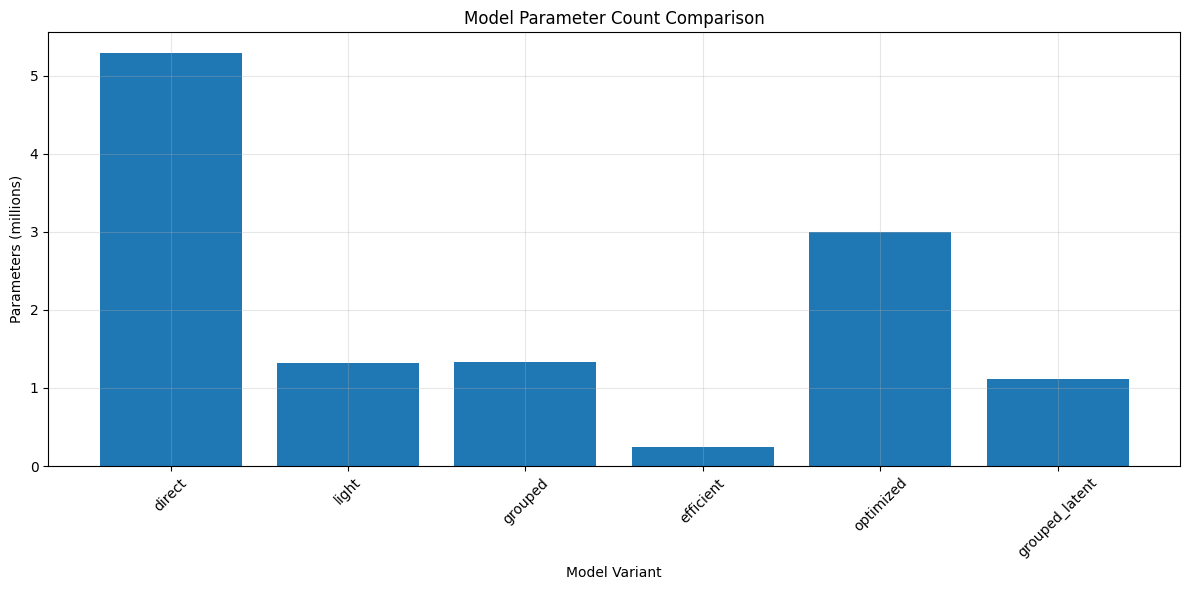

In [6]:
# Plot parameter counts
plt.figure(figsize=(12, 6))
plt.bar(stats_df["name"], stats_df["parameters_millions"])
plt.title("Model Parameter Count Comparison")
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Model Training

### Training Configuration

In [7]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

### Training Function

In [8]:
def train_model_variant(variant_name, epochs=10):
    """Train a specific model variant and return results"""
    print(f"\n{'='*80}\nTraining {variant_name} model\n{'='*80}")
    
    # Create model
    model = get_model_variant(variant_name).to(device)
    
    # Create training config
    config = create_training_config(variant_name, epochs=epochs)
    
    # Record start time
    start_time = time.time()
    
    # Train model
    train_losses, val_losses, trained_model = train_autoencoder(
        model, train_loader, val_loader, config, disable_epoch_bars=True
    )
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Get final losses
    final_train_loss = train_losses[-1] if train_losses else float('inf')
    final_val_loss = val_losses[-1] if val_losses else float('inf')
    
    # Count parameters
    param_count = count_parameters(model)
    
    return {
        "name": variant_name,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "parameters": param_count,
        "training_time": training_time,
        "model": trained_model
    }

### Run Experiments


Training direct model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/direct/direct_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/direct/direct_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E1/100|Val]:   1%|█                                                                                                   | 595/59500 [02:20<3:34:56,  4.57it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Progress [E65/100|Val]:  65%|███████████████████████████████████████████████████████████████                                  | 38675/59500 [1:30:41<43:41,  7.94it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 64


Progress [E65/100|Val]:  65%|███████████████████████████████████████████████████████████████                                  | 38675/59500 [1:30:52<48:55,  7.09it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/direct/direct_checkpoint.pth
Saved best model to output/Experiments/Notebook/direct/direct_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/direct/direct_metadata.json
Epoch 65/100 | Train: 0.001870 | Val: 0.001913 | LR: 0.00010000 | ETA: 48.93m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 61.63 MB
Cached: 234.00 MB
CPU Memory Usage: 1977.96 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.001913, Best loss: 0.002028
Validation loss improved by 0.000115
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/Notebook/direct/direct_training_history.png


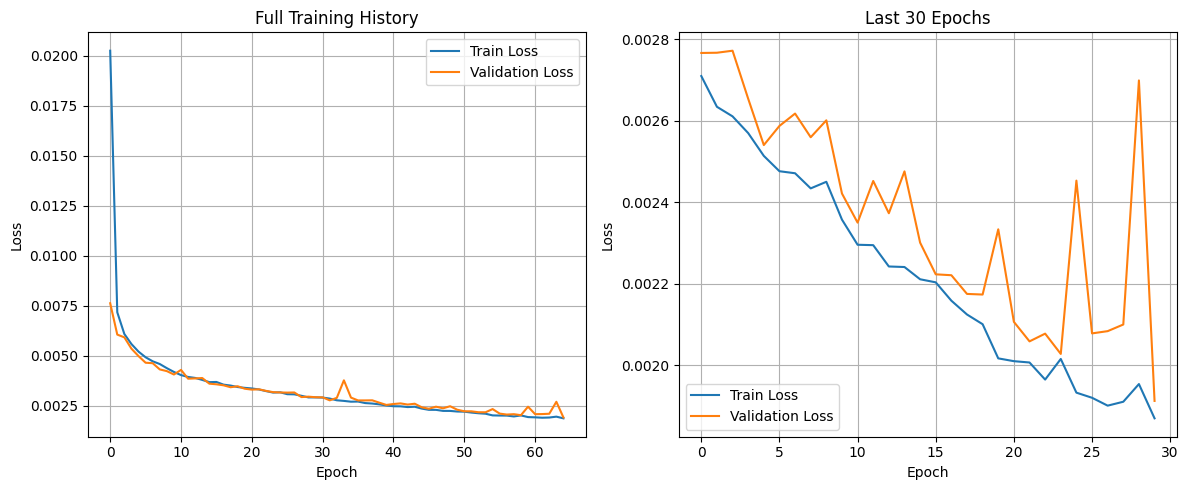

DEBUG: Plot saved and displayed successfully

Training completed in 90.87 minutes
Best validation loss: 0.001913
Completed training direct model

Training light model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/light/light_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/light/light_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E1/100|Val]:   1%|█                                                                                                   | 595/59500 [00:45<1:13:06, 13.43it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/light/light_checkpoint.pth
Saved best model to output/Experiments/Notebook/light/light_best.pth


...

Progress [E87/100|Train]:  86%|█████████████████████████████████████████████████████████████████████████████████▋             | 51170/59500 [1:13:29<10:20, 13.42it/s]

Epoch 86/100 | Train: 0.002474 | Val: 0.002609 | LR: 0.00010000 | ETA: 11.96m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 36.28 MB
Cached: 76.00 MB
CPU Memory Usage: 2012.12 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002609, Best loss: 0.002583
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 80.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 86/100, continuing to next epoch
DEBUG: Starting epoch 87/100


Progress [E87/100|Val]:  87%|████████████████████████████████████████████████████████████████████████████████████▍            | 51765/59500 [1:14:20<11:06, 11.61it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 86
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/light/light_checkpoint.pth
Saved best model to output/Experiments/Notebook/light/light_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/light/light_metadata.json
Epoch 87/100 | Train: 0.002449 | Val: 0.002510 | LR: 0.00010000 | ETA: 11.11m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 36.28 MB
Cached: 76.00 MB
CPU Memory Usage: 2012.12 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002510, Best loss: 0.002583
Validation loss improved by 0.000073
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/Notebook/light/light_training_history.png


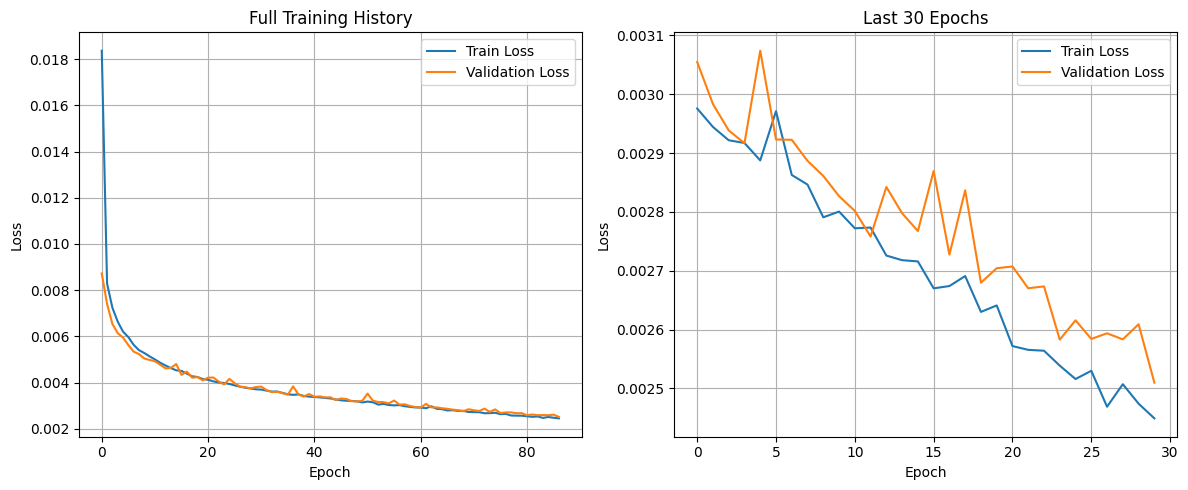

DEBUG: Plot saved and displayed successfully

Training completed in 74.35 minutes
Best validation loss: 0.002510
Completed training light model

Training grouped model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/grouped/grouped_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/grouped/grouped_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E2/100|Train]:   1%|▉                                                                                                 | 595/59500 [01:28<2:09:08,  7.60it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/grouped/grouped_checkpoint.pth
Saved best model to output/Experiments/Notebook/grouped/grouped_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/grouped/grouped_metadata.json
Epoch 1/100 | Train: 0.019643 | Val: 0.009128 | LR: 0.00010000 | ETA: 146.76m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 42.01 MB
Cached: 108.00 MB
CPU Memory Usage: 2019.73 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.009128, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/100, continuing to next epoch
DEBUG: Starting epoch 2/100


...

Progress [E96/100|Train]:  95%|██████████████████████████████████████████████████████████████████████████████████████████▎    | 56525/59500 [2:21:07<06:46,  7.32it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 94
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/grouped/grouped_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/grouped/grouped_metadata.json
Epoch 95/100 | Train: 0.002797 | Val: 0.002941 | LR: 0.00010000 | ETA: 7.43m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 42.01 MB
Cached: 108.00 MB
CPU Memory Usage: 2019.82 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002941, Best loss: 0.002906
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 89.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 95/100, continuing to next epoch
DEBUG: Starting epoch 96/100


Progress [E96/100|Val]:  96%|█████████████████████████████████████████████████████████████████████████████████████████████    | 57120/59500 [2:22:36<05:56,  6.68it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 95
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/grouped/grouped_checkpoint.pth
Saved best model to output/Experiments/Notebook/grouped/grouped_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/grouped/grouped_metadata.json
Epoch 96/100 | Train: 0.002751 | Val: 0.002866 | LR: 0.00010000 | ETA: 5.94m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 42.01 MB
Cached: 108.00 MB
CPU Memory Usage: 2019.82 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002866, Best loss: 0.002906
Validation loss improved by 0.000039
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/Notebook/grouped/grouped_training_history.png


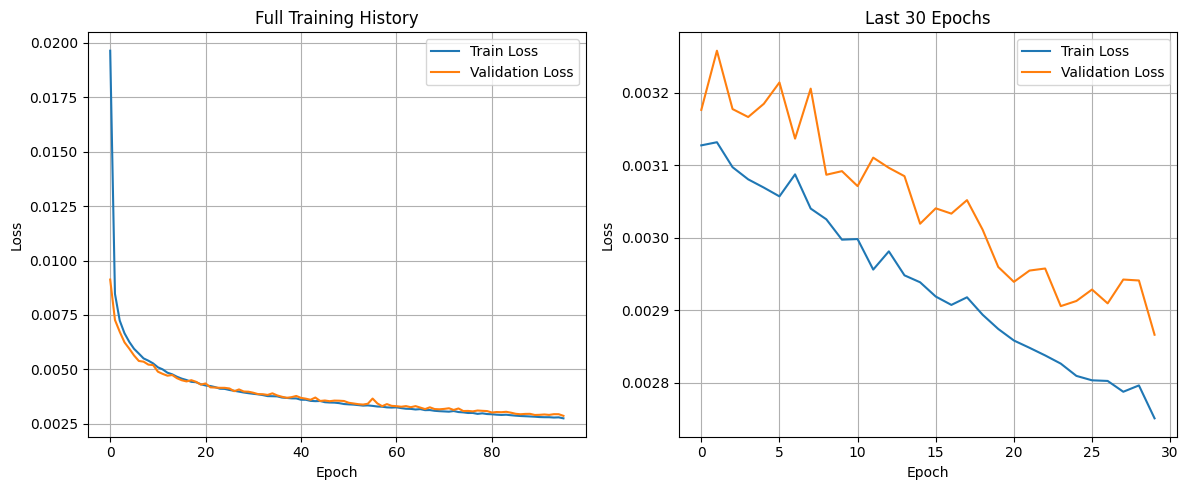

DEBUG: Plot saved and displayed successfully

Training completed in 142.61 minutes
Best validation loss: 0.002866
Completed training grouped model

Training efficient model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/efficient/efficient_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/efficient/efficient_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E2/100|Train]:   1%|▉                                                                                                 | 595/59500 [01:43<2:31:57,  6.46it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/efficient/efficient_checkpoint.pth
Saved best model to output/Experiments/Notebook/efficient/efficient_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/efficient/efficient_metadata.json
Epoch 1/100 | Train: 0.186996 | Val: 0.062276 | LR: 0.00010000 | ETA: 170.35m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 34.15 MB
Cached: 48.00 MB
CPU Memory Usage: 2040.79 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.062276, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/100, continuing to next epoch
DEBUG: Starting epoch 2/100


...

Progress [E100/100|Train]:  99%|█████████████████████████████████████████████████████████████████████████████████████████████ | 58905/59500 [2:50:41<01:31,  6.53it/s]

Epoch 99/100 | Train: 0.003336 | Val: 0.003596 | LR: 0.00010000 | ETA: 1.72m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 34.15 MB
Cached: 48.00 MB
CPU Memory Usage: 2043.14 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003596, Best loss: 0.003578
Early stopping counter: 2/5
DEBUG: EarlyStopping - No improvement, counter increased to 2/5
DEBUG: Completed epoch 99/100, continuing to next epoch
DEBUG: Starting epoch 100/100


Progress [E100/100|Val]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 59500/59500 [2:52:24<00:00,  5.75it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 99
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/efficient/efficient_checkpoint.pth
Saved best model to output/Experiments/Notebook/efficient/efficient_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/efficient/efficient_metadata.json
Epoch 100/100 | Train: 0.003329 | Val: 0.003571 | LR: 0.00010000 | ETA: 0.00m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 34.15 MB
Cached: 48.00 MB
CPU Memory Usage: 2043.14 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003571, Best loss: 0.003578
Validation loss improved by 0.000006
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 100/100, continuing to next epoch
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/Notebook/efficient/efficient_training_history.png


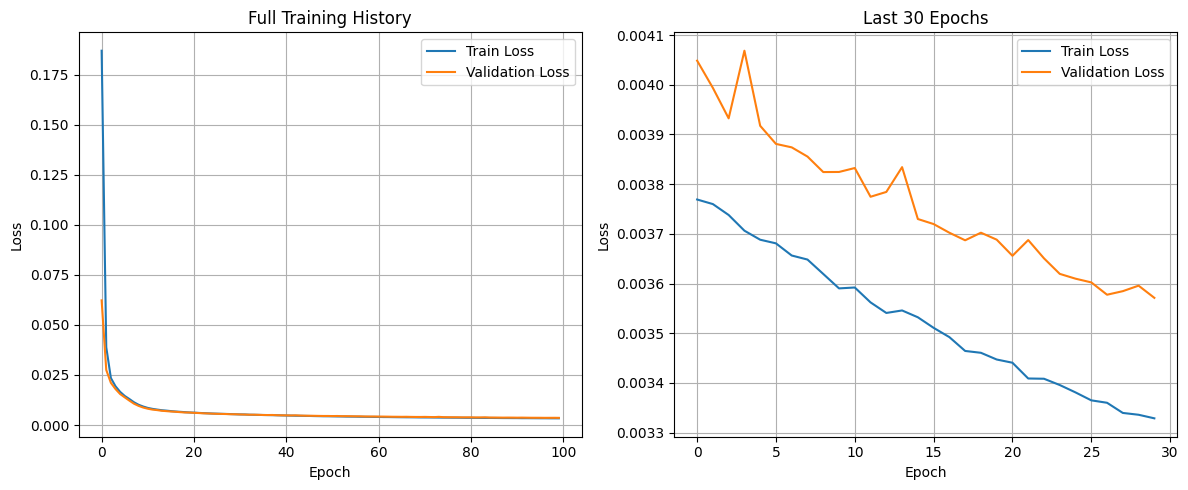

DEBUG: Plot saved and displayed successfully

Training completed in 172.42 minutes
Best validation loss: 0.003571
Completed training efficient model

Training optimized model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/optimized/optimized_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/optimized/optimized_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E1/100|Val]:   1%|█                                                                                                     | 595/59500 [00:33<52:53, 18.56it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/optimized/optimized_checkpoint.pth


...

Epoch 42/100 | Train: 0.003670 | Val: 0.003769 | LR: 0.00005000 | ETA: 38.51m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 67.42 MB
Cached: 134.00 MB
CPU Memory Usage: 2057.11 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003769, Best loss: 0.003681
Early stopping counter: 6/5
DEBUG: EarlyStopping - No improvement, counter increased to 6/5
Early stopping triggered. Best epoch was 35.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 42/100, continuing to next epoch
DEBUG: Starting epoch 43/100


Progress [E43/100|Val]:  43%|██████████████████████████████████████████▌                                                        | 25585/59500 [28:27<31:28, 17.96it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 42
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/optimized/optimized_checkpoint.pth
Saved best model to output/Experiments/Notebook/optimized/optimized_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/optimized/optimized_metadata.json
Epoch 43/100 | Train: 0.003494 | Val: 0.003486 | LR: 0.00005000 | ETA: 37.85m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 67.42 MB
Cached: 134.00 MB


Progress [E43/100|Val]:  43%|██████████████████████████████████████████▌                                                        | 25585/59500 [28:33<37:51, 14.93it/s]

CPU Memory Usage: 2057.11 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003486, Best loss: 0.003681
Validation loss improved by 0.000196
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/Notebook/optimized/optimized_training_history.png


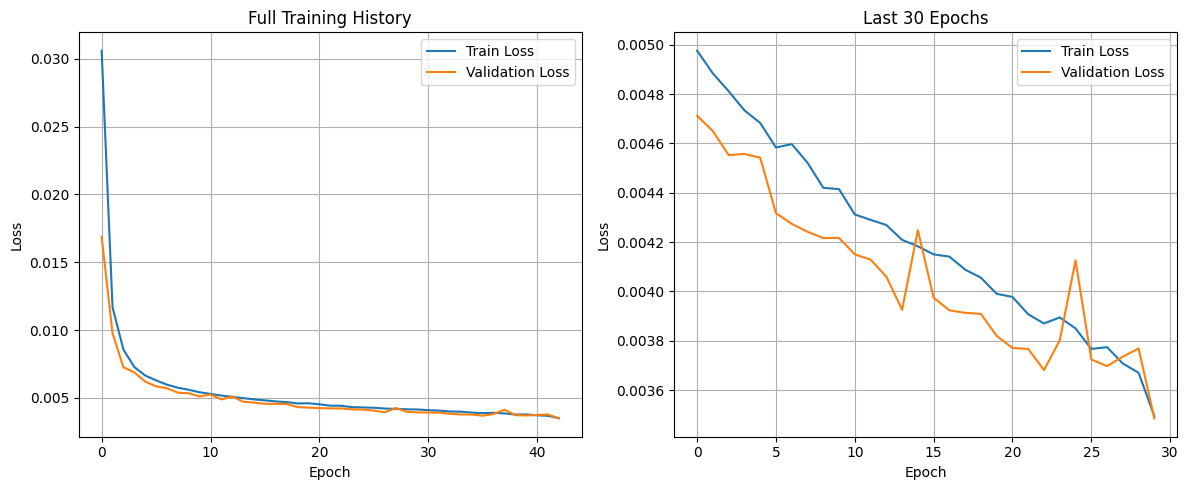

DEBUG: Plot saved and displayed successfully

Training completed in 28.56 minutes
Best validation loss: 0.003486
Completed training optimized model

Training grouped_latent model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
No checkpoint found at output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/100|Train]:   0%|                                                                                                              | 0/59500 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/100


Progress [E2/100|Train]:   1%|█                                                                                                   | 595/59500 [00:41<58:39, 16.74it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
Saved best model to output/Experiments/Notebook/grouped_latent/grouped_latent_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/grouped_latent/grouped_latent_metadata.json
Epoch 1/100 | Train: 0.122773 | Val: 0.105407 | LR: 0.00010000 | ETA: 68.82m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 57.35 MB
Cached: 104.00 MB
CPU Memory Usage: 2057.62 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.105407, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/100, continuing to next epoch
DEBUG: Starting epoch 2/100


...

Progress [E25/100|Train]:  24%|███████████████████████▎                                                                         | 14280/59500 [16:32<43:34, 17.30it/s]

Epoch 24/100 | Train: 0.030872 | Val: 0.034880 | LR: 0.00005000 | ETA: 52.39m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 57.35 MB
Cached: 104.00 MB
CPU Memory Usage: 2057.64 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.034880, Best loss: 0.031238
Early stopping counter: 6/5
DEBUG: EarlyStopping - No improvement, counter increased to 6/5
Early stopping triggered. Best epoch was 17.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 24/100, continuing to next epoch
DEBUG: Starting epoch 25/100


Progress [E25/100|Val]:  25%|████████████████████████▊                                                                          | 14875/59500 [17:14<51:44, 14.37it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 24
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/Notebook/grouped_latent/grouped_latent_checkpoint.pth
Saved best model to output/Experiments/Notebook/grouped_latent/grouped_latent_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/Notebook/grouped_latent/grouped_latent_metadata.json
Epoch 25/100 | Train: 0.030714 | Val: 0.030594 | LR: 0.00005000 | ETA: 51.75m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 57.35 MB
Cached: 104.00 MB
CPU Memory Usage: 2057.64 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.030594, Best loss: 0.031238
Validation loss improved by 0.000644
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/Notebook/grouped_latent/grouped_latent_training_history.png


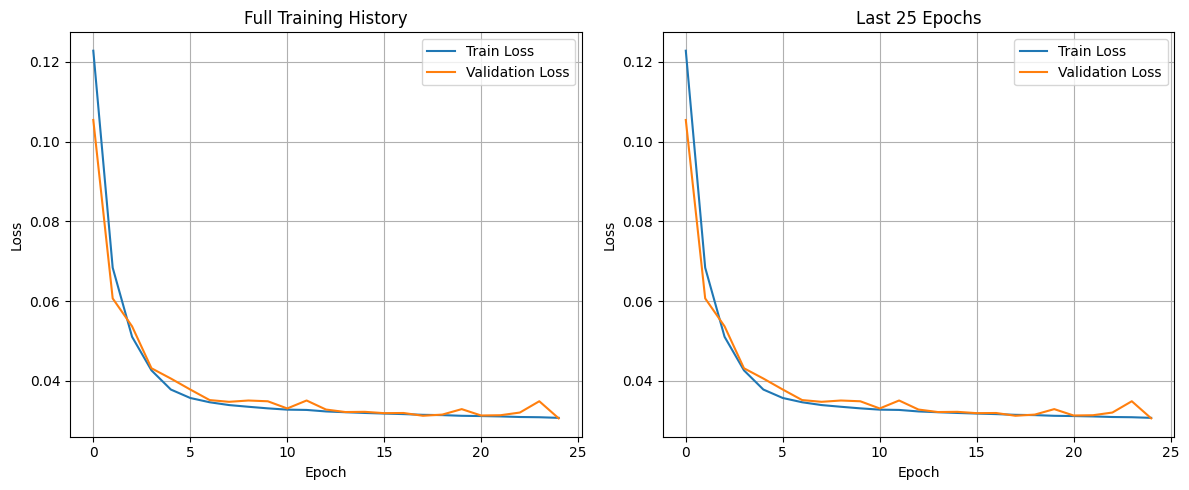

DEBUG: Plot saved and displayed successfully

Training completed in 17.26 minutes
Best validation loss: 0.030594
Completed training grouped_latent model


In [9]:
# Set number of epochs
num_epochs = 100  # Adjust as needed

# Model variants to train
# variants_to_train = ["optimized", "grouped_latent"]  # Focus on new models
variants_to_train = ["direct", "light",  "grouped", "efficient", "optimized", "grouped_latent"]

# Train each model variant
results = []
for variant in variants_to_train:
    try:
        result = train_model_variant(variant, epochs=num_epochs)
        results.append(result)
        print(f"Completed training {variant} model")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {variant} model: {str(e)}")
        import traceback
        traceback.print_exc()

## 5. Results Analysis

In [11]:
# Create results dataframe
results_df = pd.DataFrame([
    {
        "name": r["name"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in results
])

display(results_df)

,name,final_train_loss,final_val_loss,parameters,parameters_millions,training_time,training_time_minutes
0,direct,0.001870,0.001913,5292497,5.292497,5453.565528,90.892759
1,light,0.002449,0.002510,1324329,1.324329,4460.828818,74.347147
2,grouped,0.002751,0.002866,1326737,1.326737,8556.470665,142.607844
3,efficient,0.003329,0.003571,243857,0.243857,10346.268842,172.437814
4,optimized,0.003494,0.003486,2992913,2.992913,1713.560471,28.559341
5,grouped_latent,0.030714,0.030594,1112589,1.112589,1035.352195,17.255870


### Visualization of Results

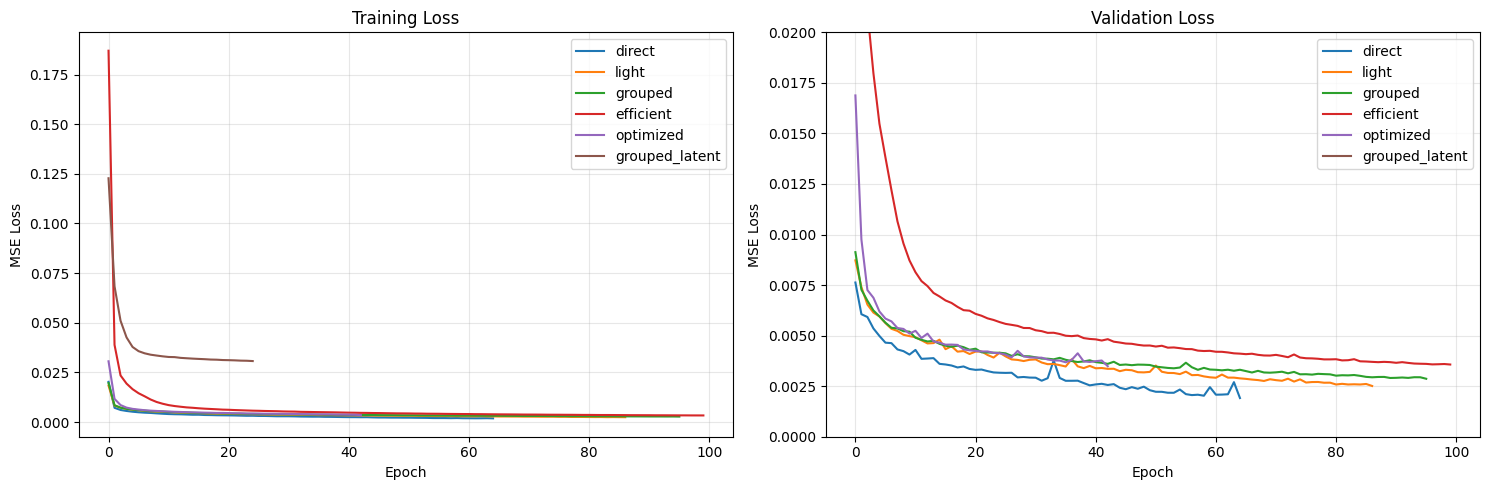

In [20]:
# Plot training and validation loss curves
plt.figure(figsize=(15, 5))

# Plot training loss
plt.subplot(1, 2, 1)
for r in results:
    plt.plot(r["train_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)

# Plot validation loss
plt.subplot(1, 2, 2)
for r in results:
    plt.plot(r["val_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0,0.02)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_comparison.png"))
plt.show()

#### Compare Model Metrics

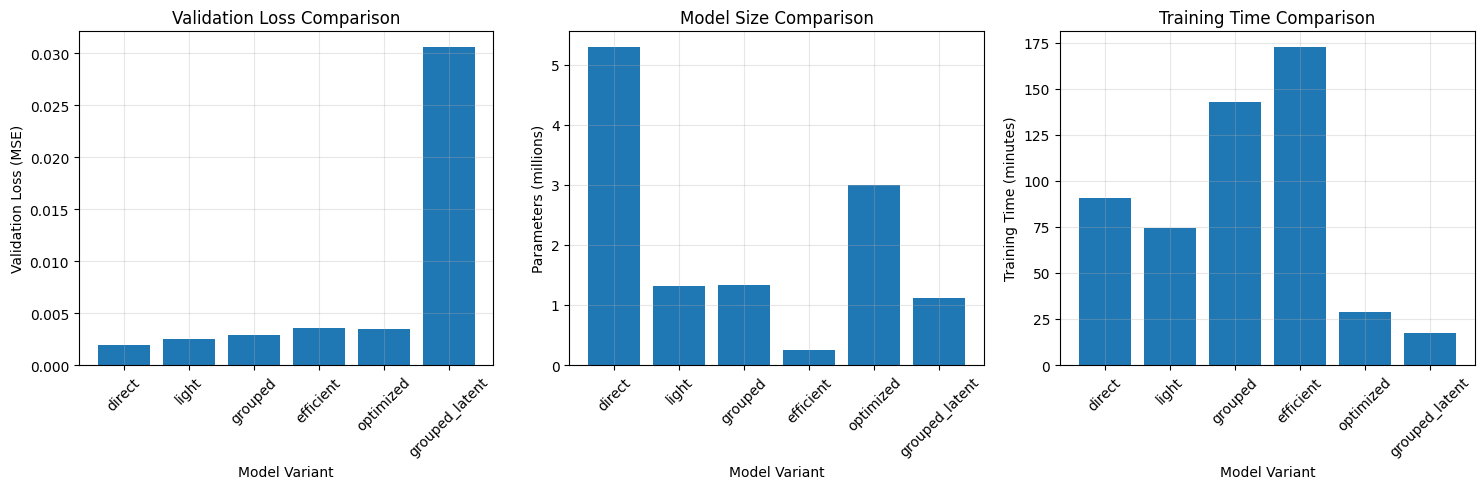

In [13]:
# Create comparison plots
plt.figure(figsize=(15, 5))

# Plot validation loss comparison
plt.subplot(1, 3, 1)
plt.bar(results_df["name"], results_df["final_val_loss"])
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot parameter count comparison
plt.subplot(1, 3, 2)
plt.bar(results_df["name"], results_df["parameters_millions"])
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.title("Model Size Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot training time comparison
plt.subplot(1, 3, 3)
plt.bar(results_df["name"], results_df["training_time_minutes"])
plt.xlabel("Model Variant")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "metrics_comparison.png"))
plt.show()

#### Reconstruction Visualization

2025-09-25 11:19:27,310 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/reconstruction_comparison.png
2025-09-25 11:19:28,697 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/direct_reconstruction.png
2025-09-25 11:19:30,364 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/light_reconstruction.png
2025-09-25 11:19:31,760 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/grouped_reconstruction.png
2025-09-25 11:19:33,425 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/efficient_reconstruction.png
2025-09-25 11:19:34,806 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/optimized_reconstruction.png
2025-09-25 11:19:36,555 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/Notebook/grouped_latent_reconstruction.png


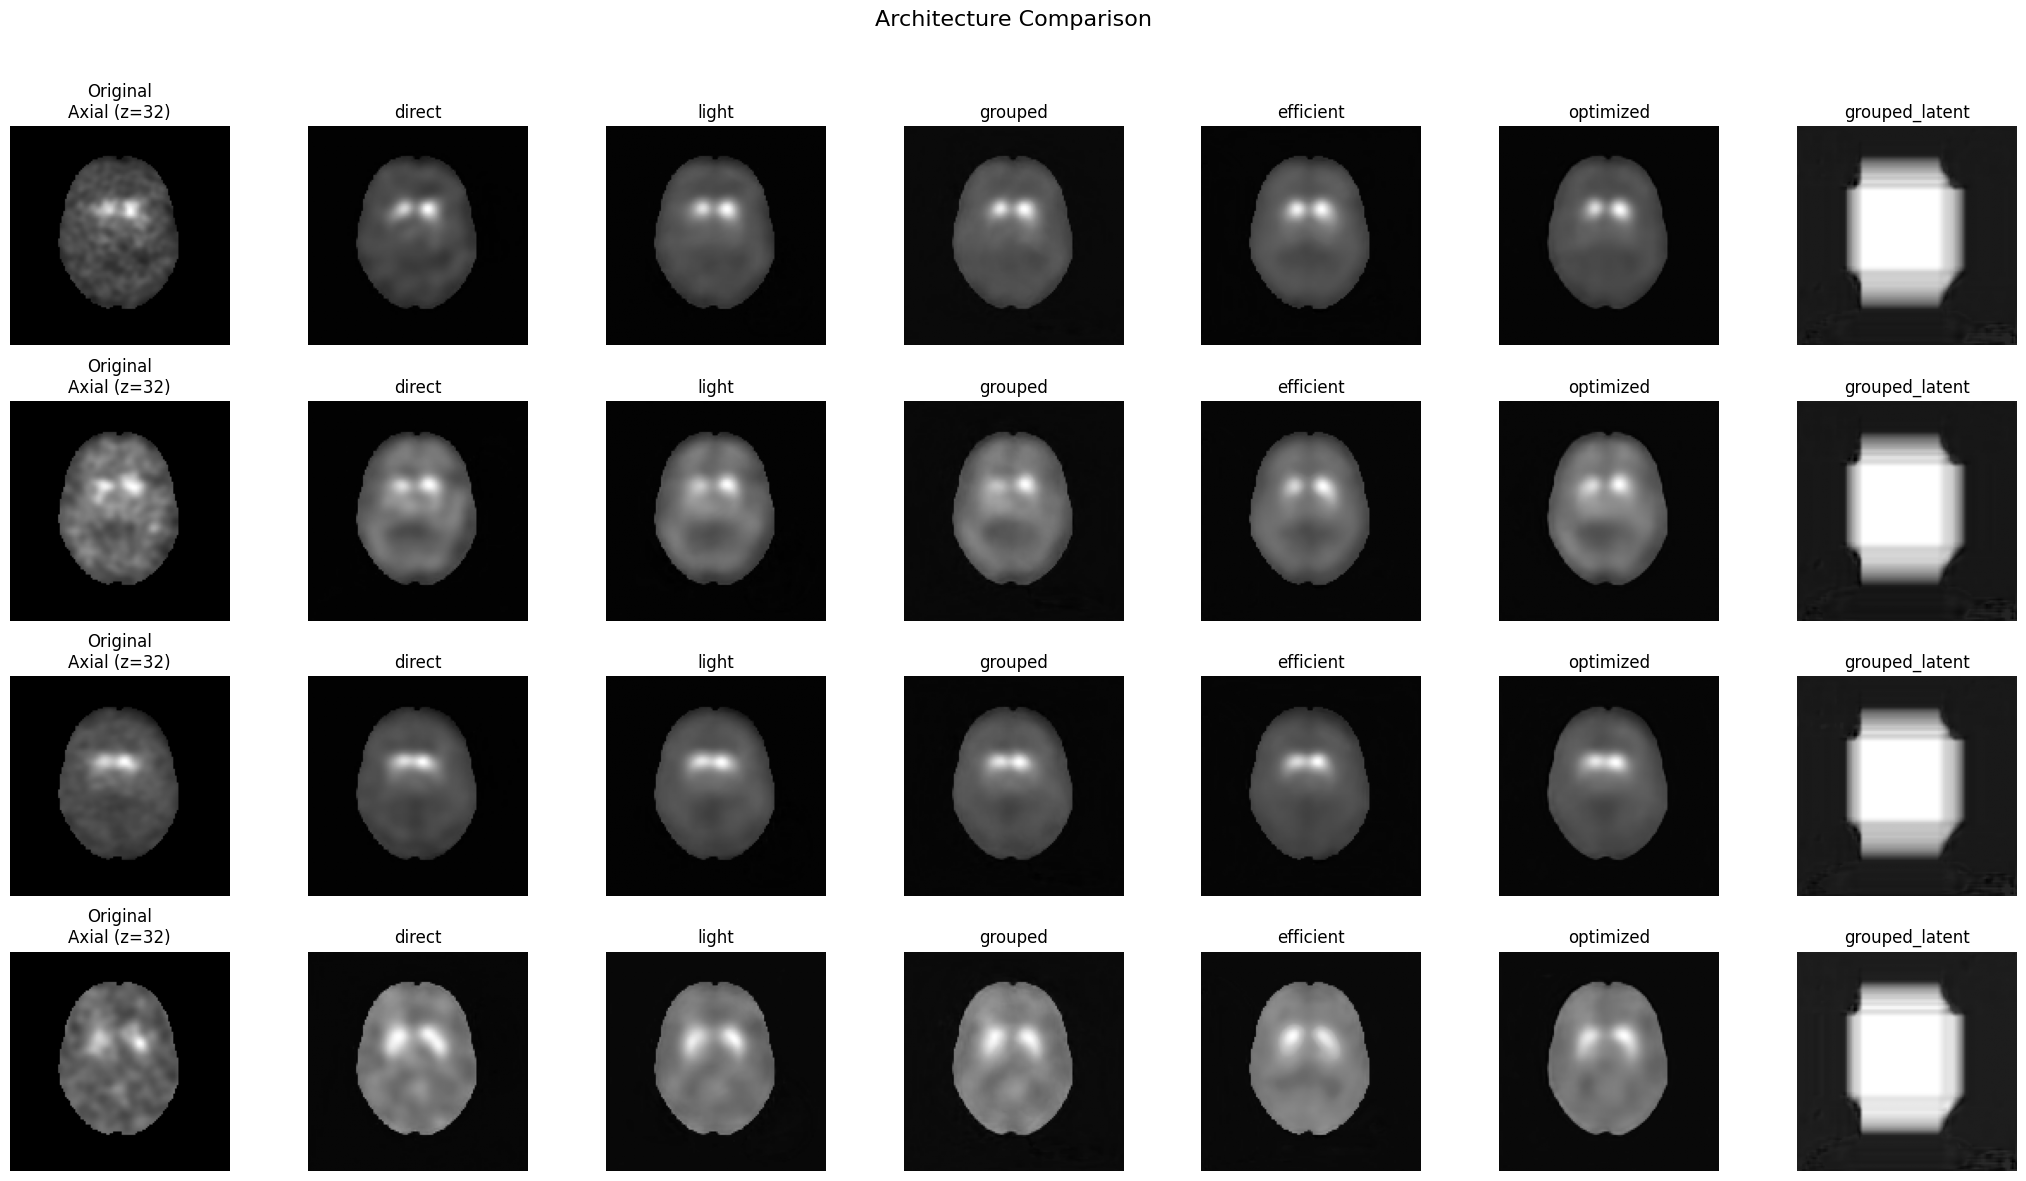

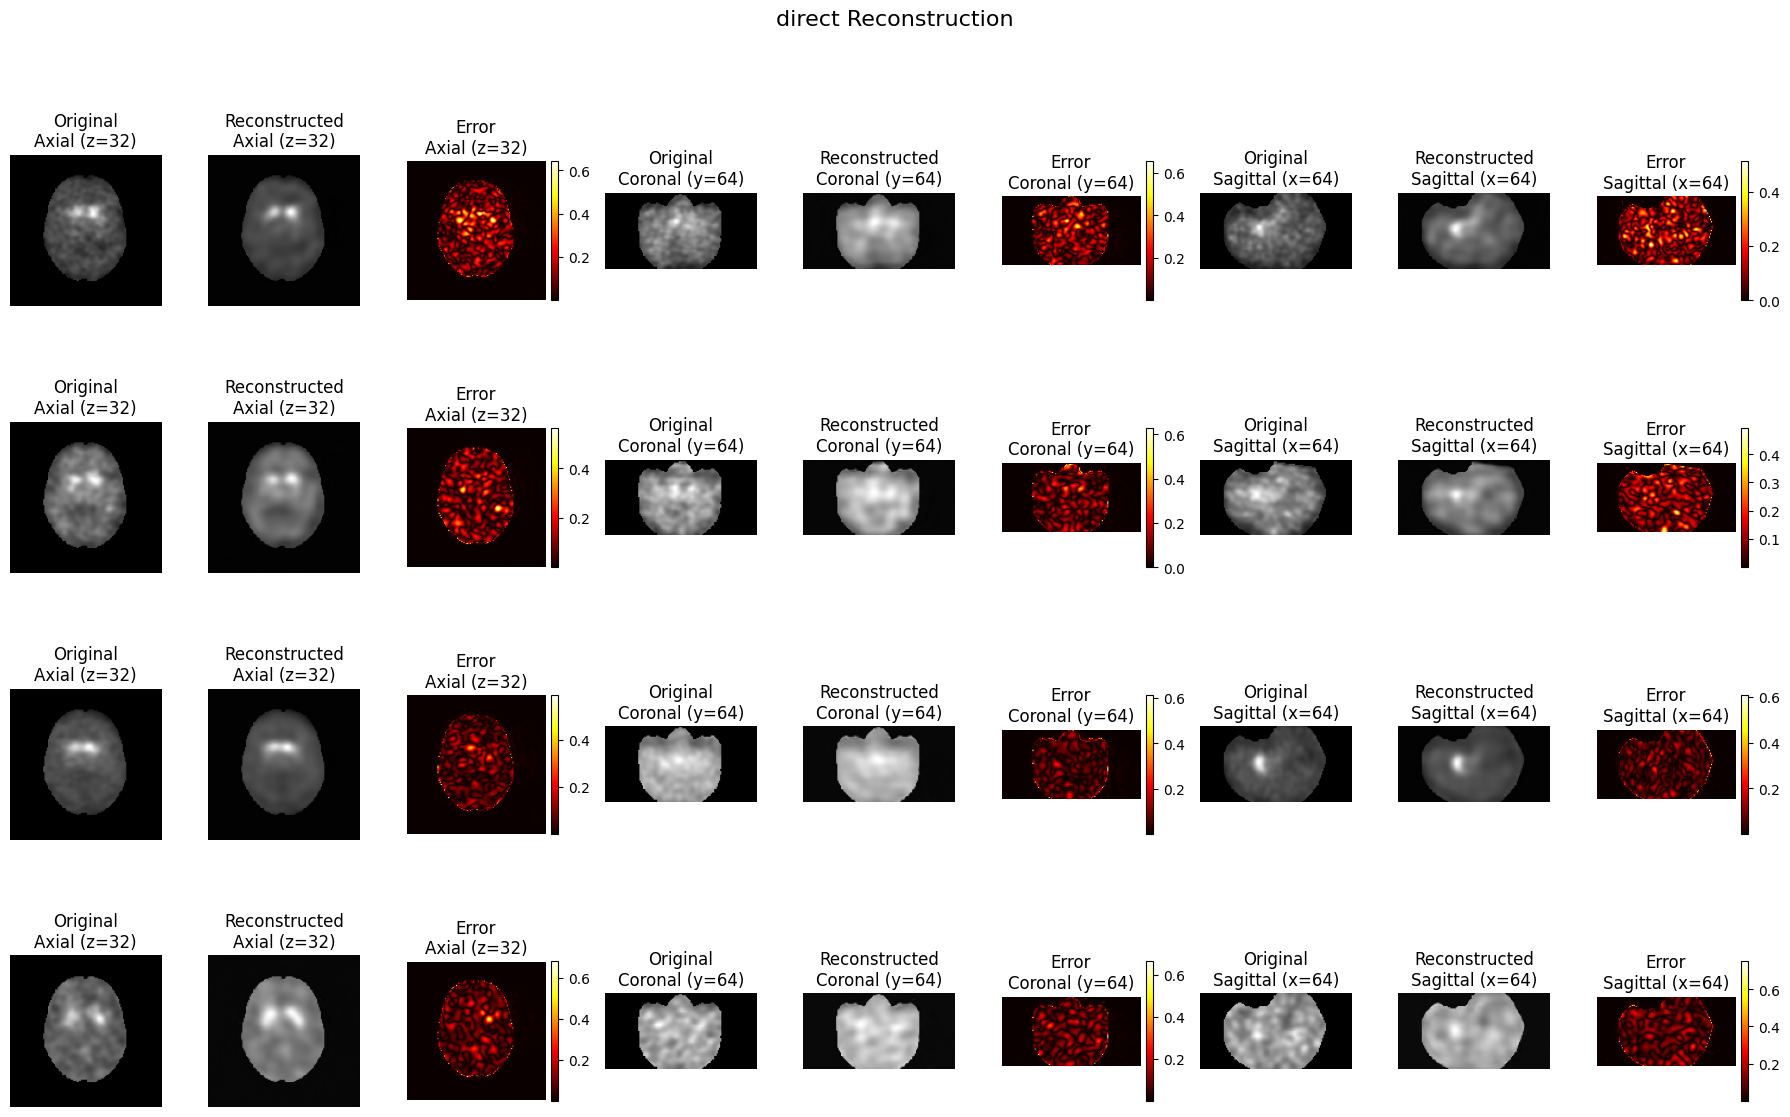

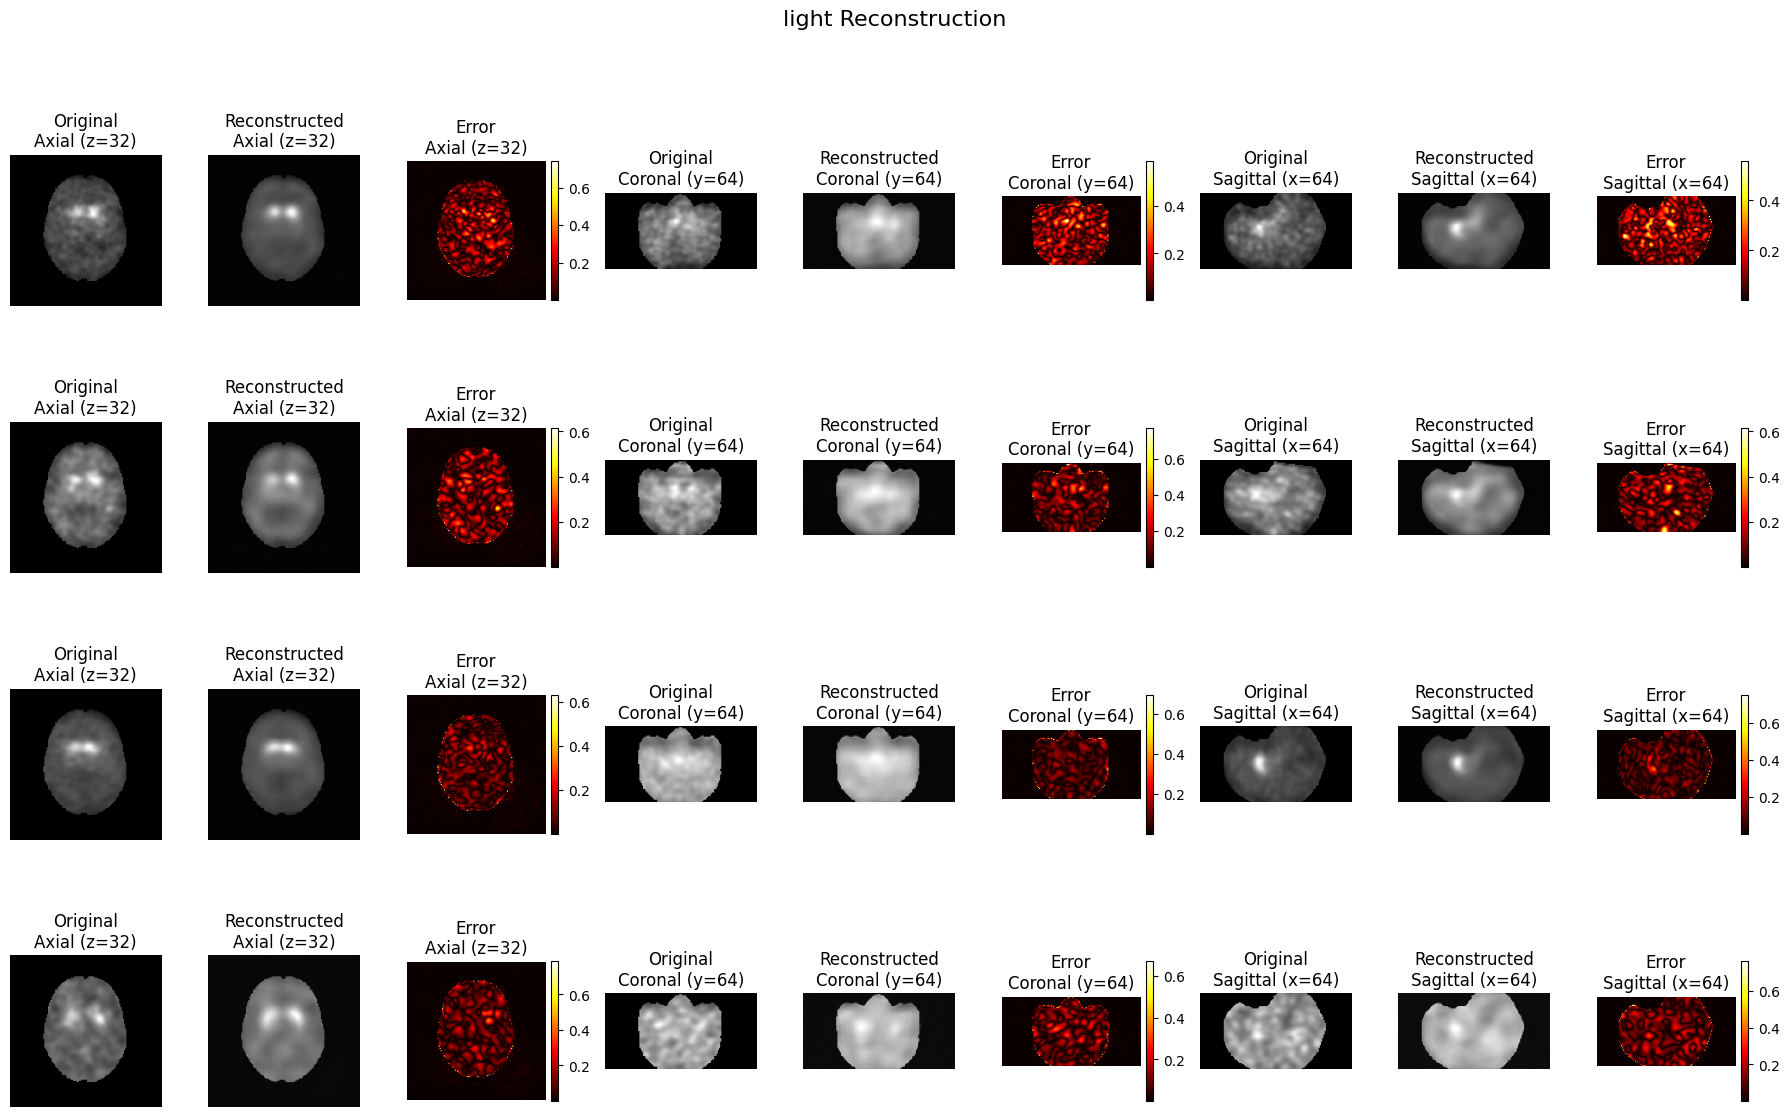

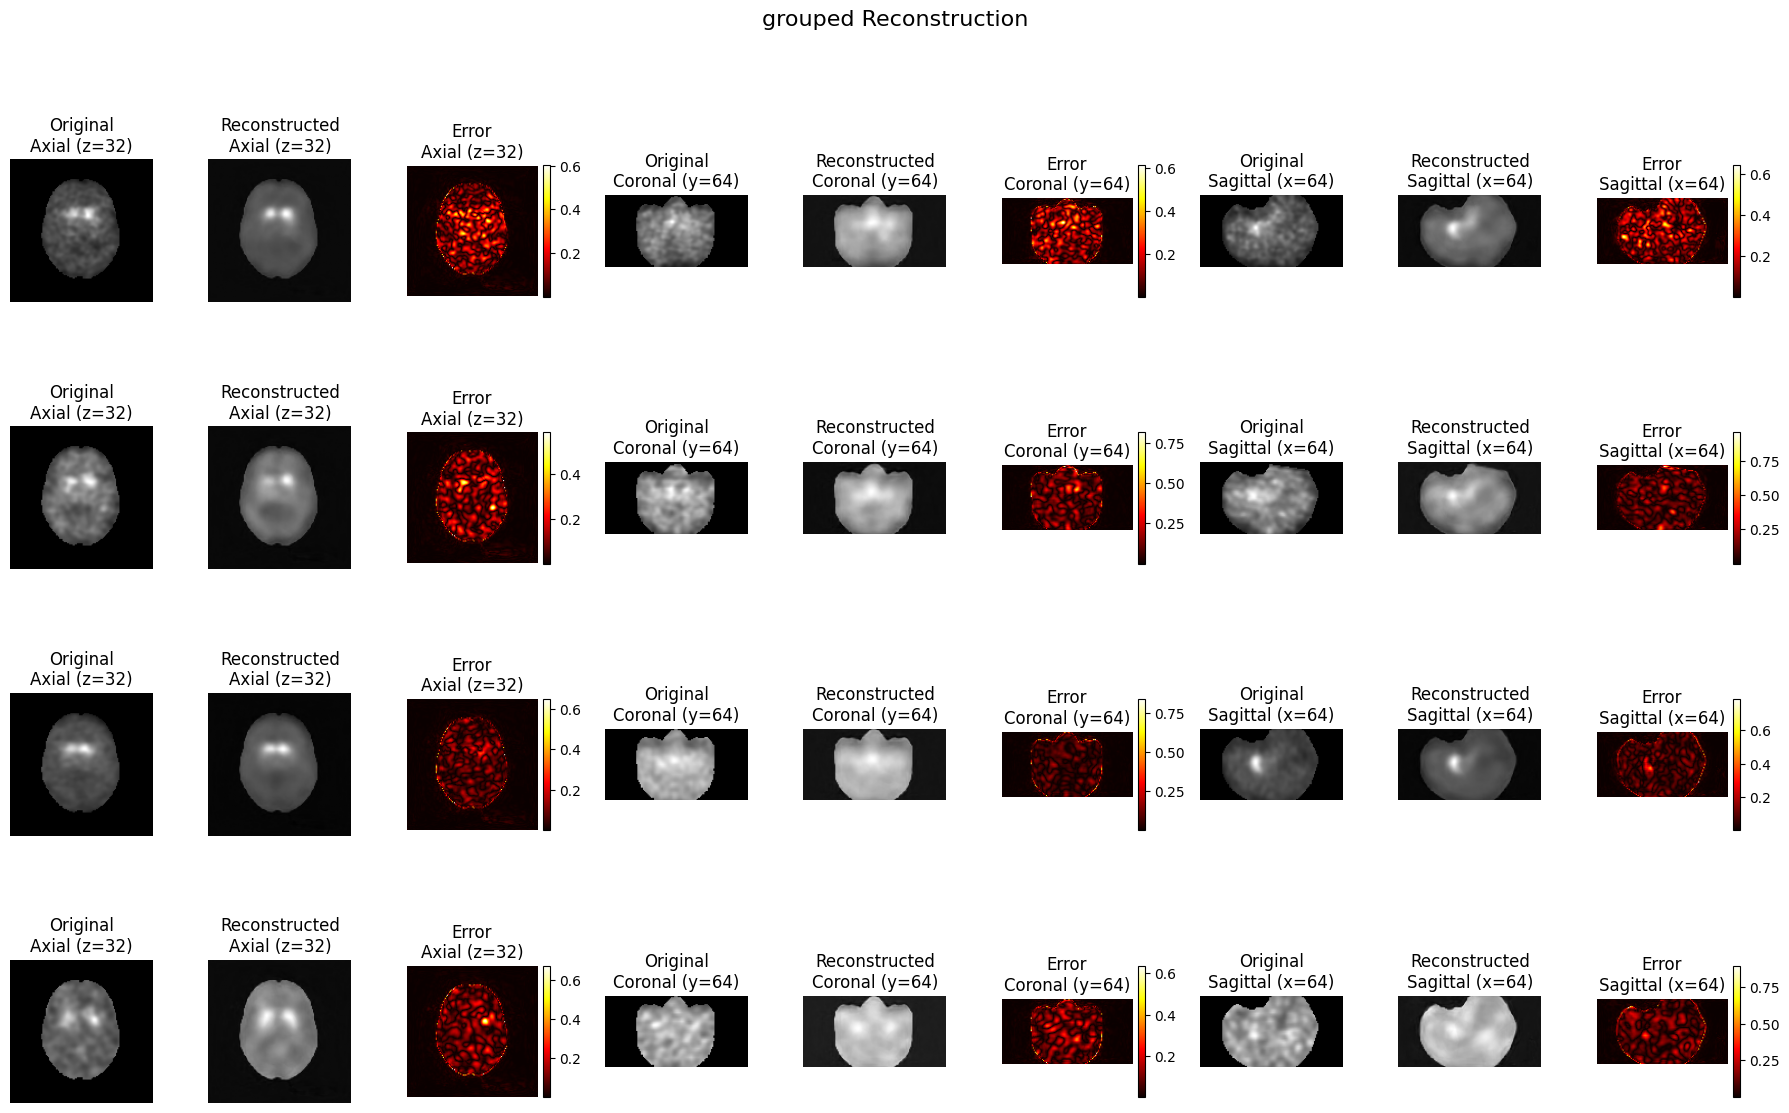

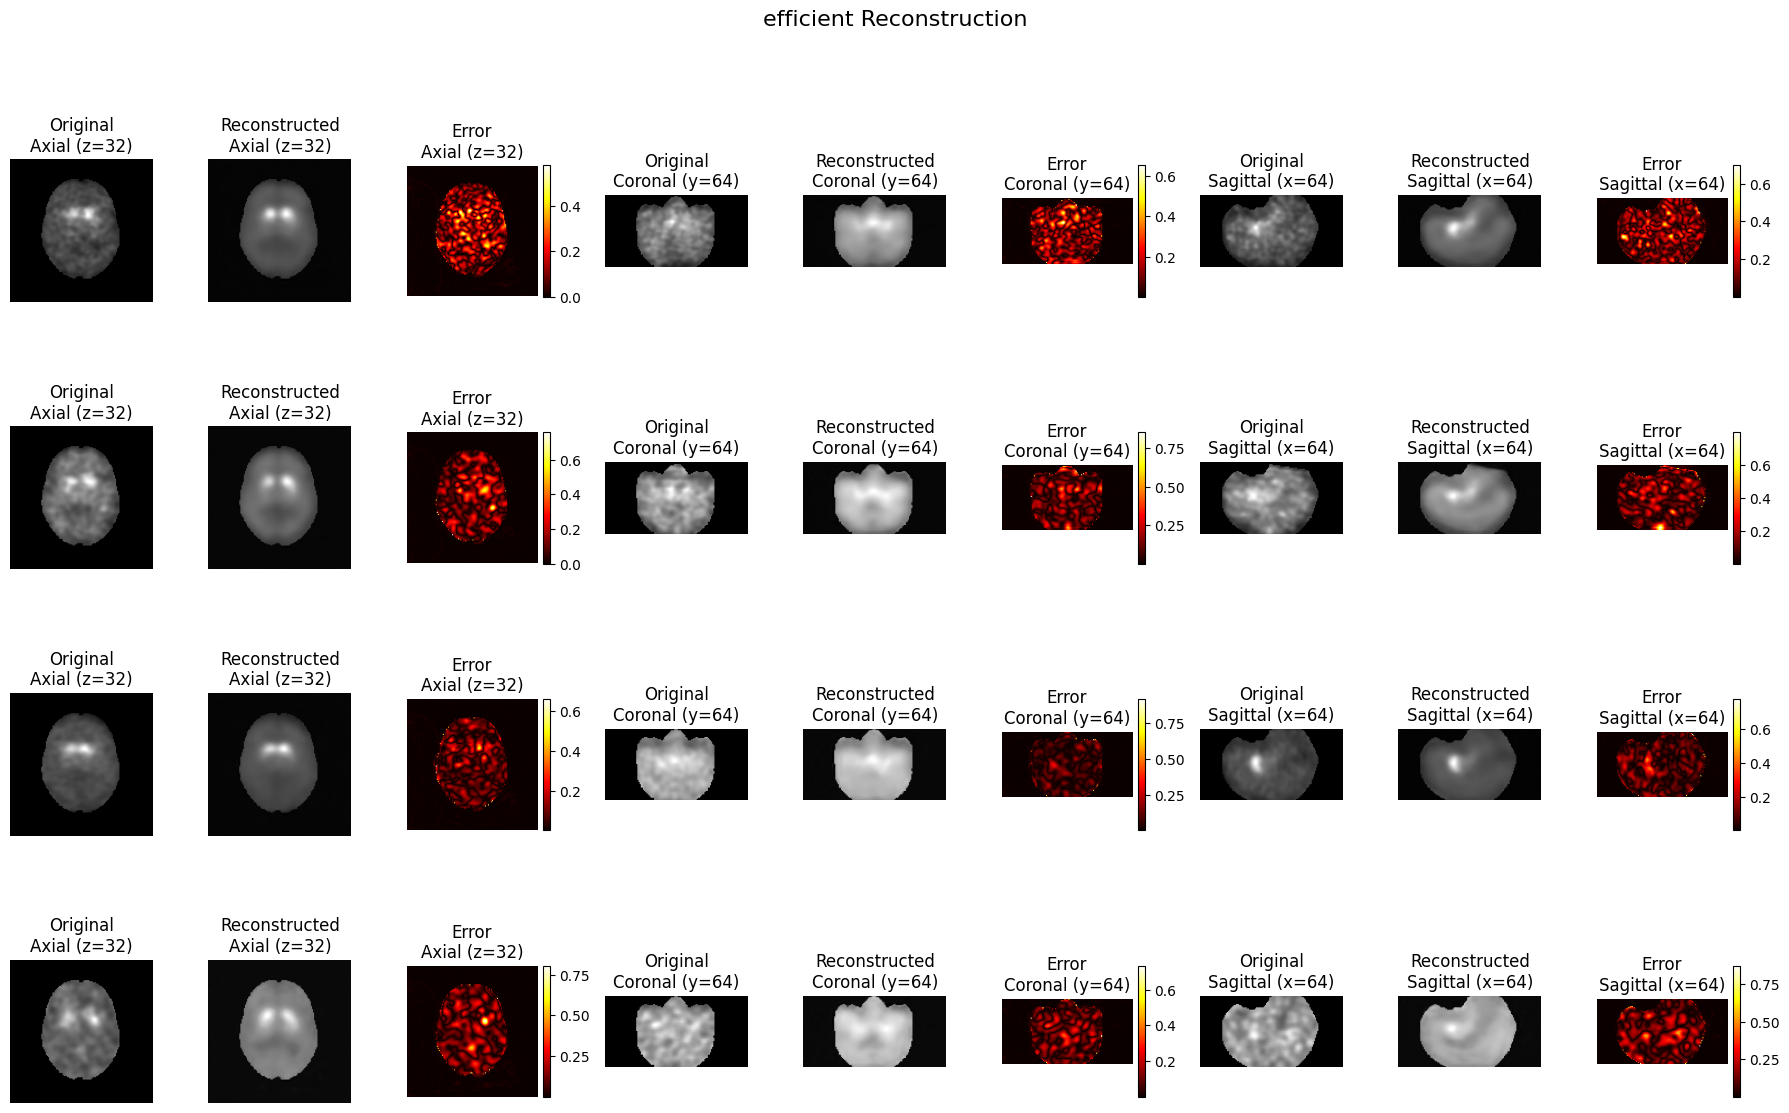

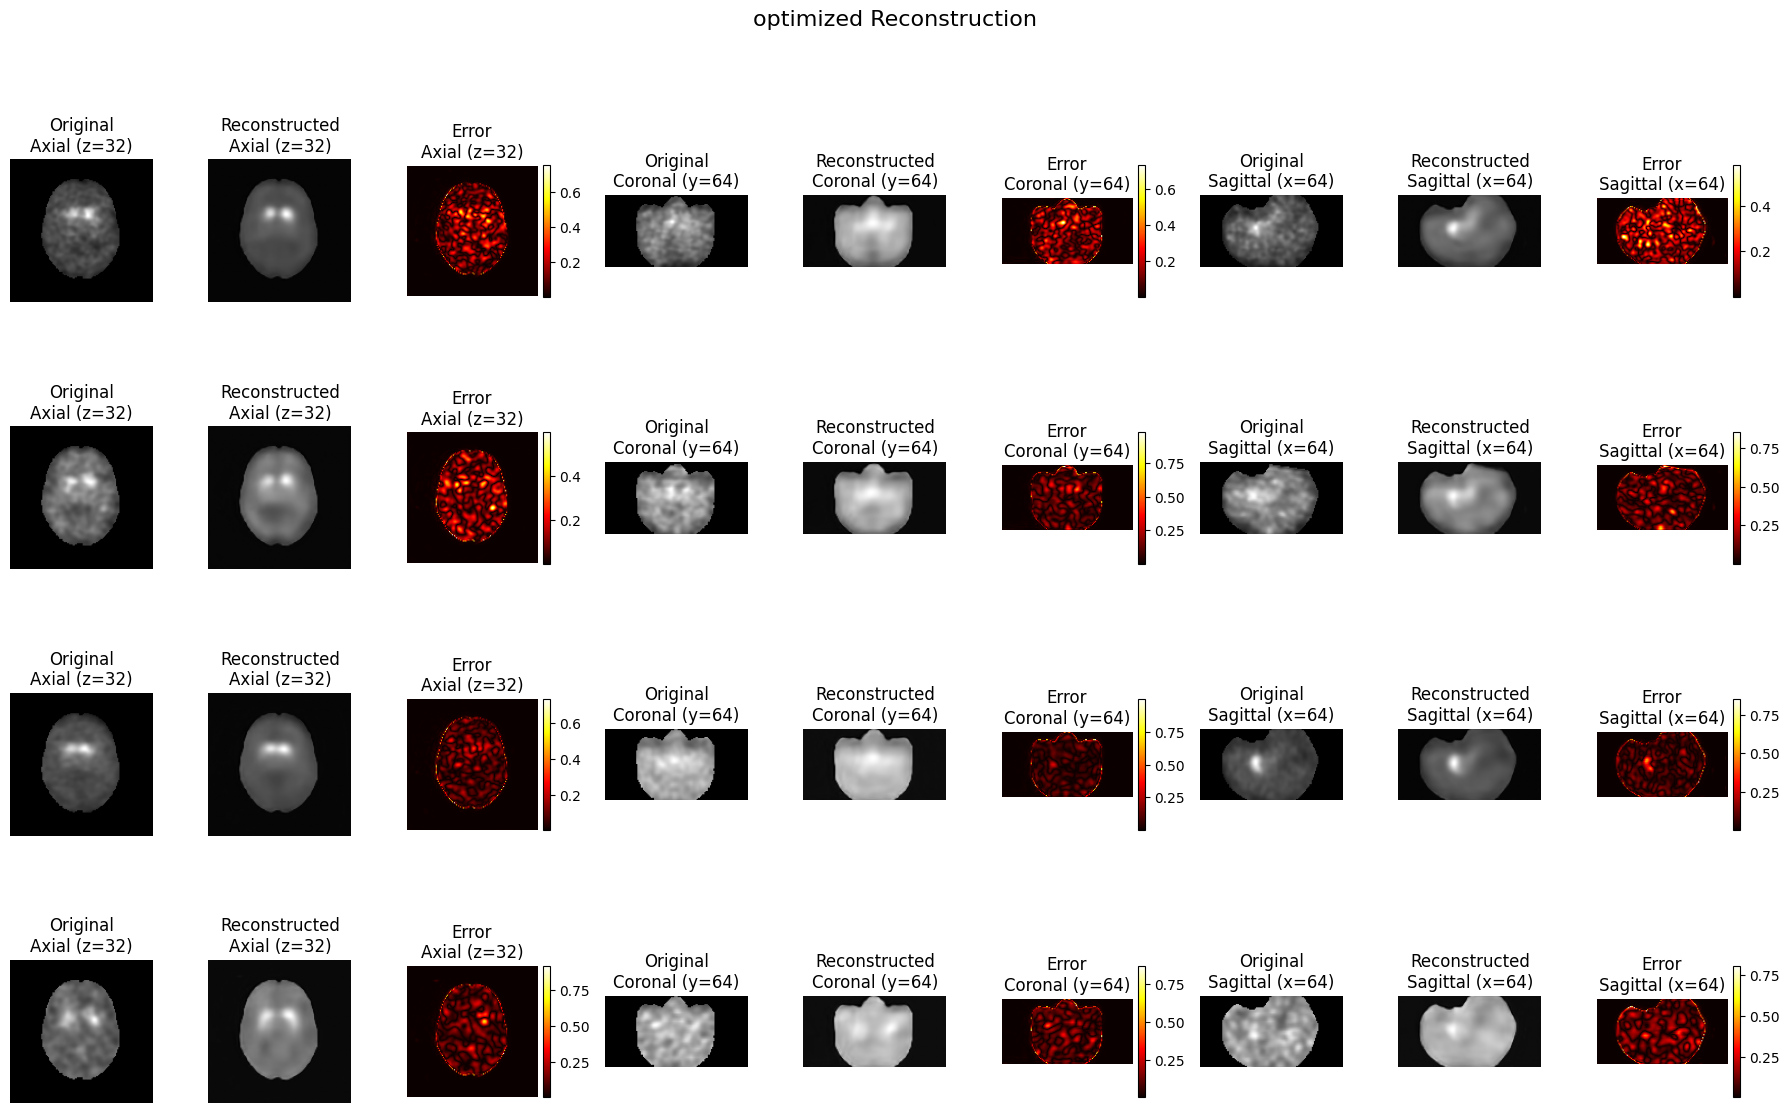

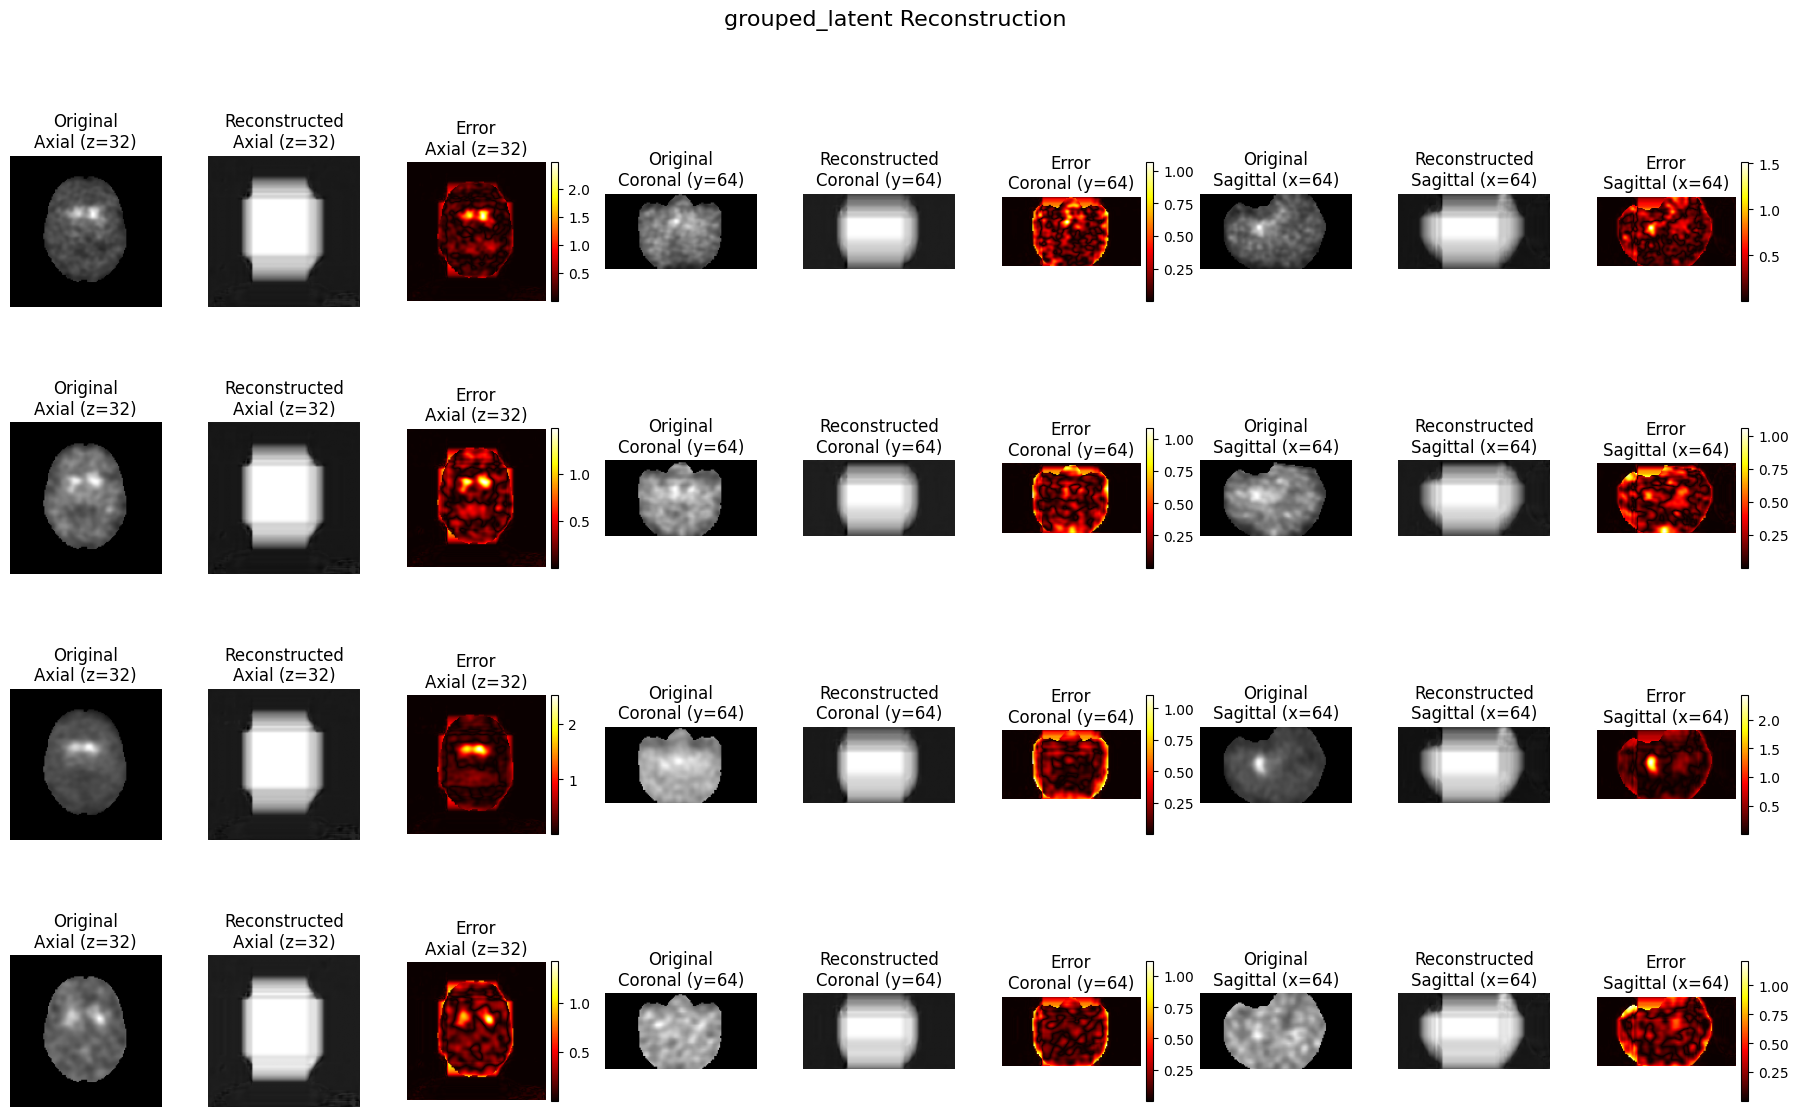

In [14]:
def visualize_reconstructions(results, sample_batch=None):
    """Visualize reconstructions from different models"""
    # Get a batch from validation set if not provided
    if sample_batch is None:
        for batch in val_loader:
            sample_batch = batch
            break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(r["name"])
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Architecture Comparison",
        save_path=os.path.join(output_dir, "reconstruction_comparison.png")
    )
    
    # Generate detailed visualizations for each variant
    for i, name in enumerate(model_names):
        visualizer.visualize_slice_comparison(
            original_volumes, reconstructions[i],
            title=f"{name} Reconstruction",
            save_path=os.path.join(output_dir, f"{name}_reconstruction.png")
        )

# Visualize reconstructions
try:
    visualize_reconstructions(results)
except Exception as e:
    print(f"Error visualizing reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

## 6. Memory Usage Analysis

In [25]:
def analyze_memory_usage(model_names):
    """Analyze memory usage during inference for different models"""
    memory_stats = []
    
    for name in model_names:
        # Create model
        model = get_model_variant(name).to(device)
        
        # Create dummy input
        dummy_input = torch.zeros((batch_size, 1, 64, 128, 128), device=device)
        
        # Warm up
        _ = model(dummy_input)
        
        # Measure memory
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        # with torch.no_grad():
        _ = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        memory_stats.append({
            "name": name,
            "memory_mb": memory_used
        })
        
        # Clean up
        del model
        torch.cuda.empty_cache()
    
    return pd.DataFrame(memory_stats)

In [27]:
# Analyze memory usage
memory_df = analyze_memory_usage(model_variants)
display(memory_df)

,name,memory_mb
0,direct,6141.423828
1,light,2995.197754
2,grouped,5886.895020
3,efficient,10472.836426
4,optimized,1869.597168
5,grouped_latent,1254.404297


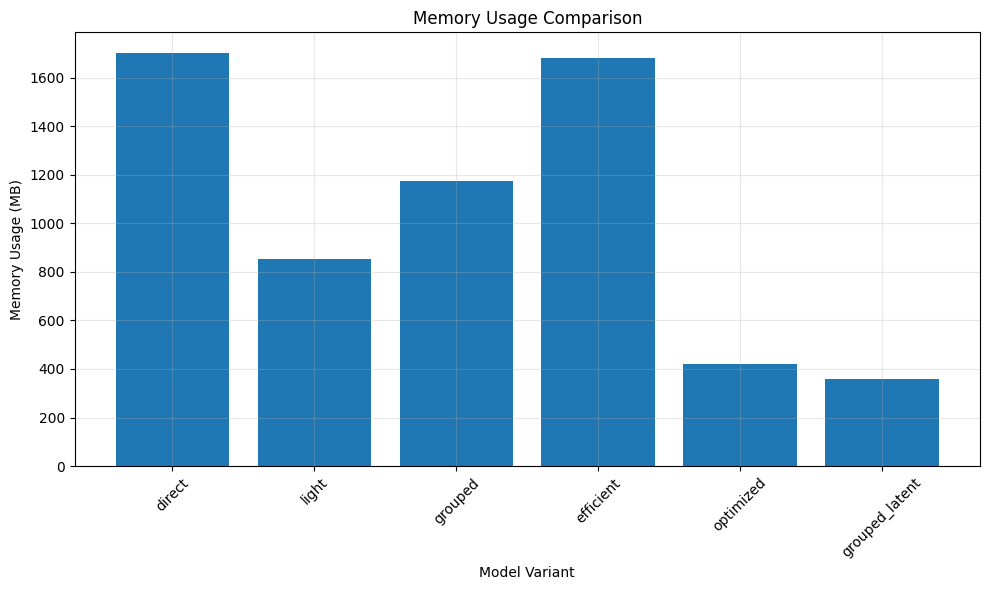

In [17]:
# Plot memory usage
plt.figure(figsize=(10, 6))
plt.bar(memory_df["name"], memory_df["memory_mb"])
plt.xlabel("Model Variant")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Comparison")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "memory_comparison.png"))
plt.show()

## 7. Detailed Analysis of Optimization Steps

We'll analyze each optimization step individually to understand its impact:

1. Starting directly with strided convolution and fewer filters
2. Reducing channels at the end of each block with 1x1 convolutions
3. Grouped convolution bottleneck architecture

For each optimization, we'll create a model variant that implements only that specific change,
train it, and compare its performance to the baseline.

### Step 1: Model with only direct strided convolution start

In [18]:
class Step1Model(nn.Module):
    """Model that only implements the first optimization step:
    Starting directly with strided convolution and fewer filters"""
    def __init__(self, initial_filters=4):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            # Start directly with strided convolution as requested
            # 1->4 strided, 4->32 non-strided
            OptimizedConvBlock(1, initial_filters, stride=2),      # -> (4, 32, 64, 64)
            OptimizedConvBlock(initial_filters, 32),               # -> (32, 32, 64, 64)
            
            # Rest of the encoder follows the original pattern
            OptimizedConvBlock(32, 64, stride=2),                  # -> (64, 16, 32, 32)
            OptimizedConvBlock(64, 64),                            # -> (64, 16, 32, 32)
            
            OptimizedConvBlock(64, 128, stride=2),                 # -> (128, 8, 16, 16)
            OptimizedConvBlock(128, 128),                          # -> (128, 8, 16, 16)
            
            OptimizedConvBlock(128, 256, stride=2),                # -> (256, 4, 8, 8)
            OptimizedConvBlock(256, 256),                          # -> (256, 4, 8, 8)
        )
        
        # Decoder (same as original)
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(256, 128),
            OptimizedConvBlock(128, 128),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(128, 64),
            OptimizedConvBlock(64, 64),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 32),
            OptimizedConvBlock(32, 32),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(32, 16),
            OptimizedConvBlock(16, 16),
            
            nn.Conv3d(16, 1, kernel_size=1)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

### Step 2: Model with only channel reduction blocks

In [ ]:
class Step2Model(nn.Module):
    """Model that only implements the second optimization step:
    Reducing channels at the end of each block with 1x1 convolutions"""
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            # Initial feature extraction (same as original)
            OptimizedConvBlock(1, 16),  # (1, 64, 128, 128) -> (16, 64, 128, 128)
            
            # First downsampling block with channel reduction
            OptimizedConvBlock(16, 32, stride=2),                  # -> (32, 32, 64, 64)
            OptimizedConvBlock(32, 32),                            # -> (32, 32, 64, 64)
            ChannelReductionBlock(32),                             # -> (8, 32, 64, 64)
            
            # Second downsampling block with channel reduction
            OptimizedConvBlock(8, 64, stride=2),                   # -> (64, 16, 32, 32)
            OptimizedConvBlock(64, 64),                            # -> (64, 16, 32, 32)
            ChannelReductionBlock(64),                             # -> (16, 16, 32, 32)
            
            # Third downsampling block with channel reduction
            OptimizedConvBlock(16, 128, stride=2),                 # -> (128, 8, 16, 16)
            OptimizedConvBlock(128, 128),                          # -> (128, 8, 16, 16)
            ChannelReductionBlock(128),                            # -> (32, 8, 16, 16)
            
            # Fourth downsampling block with channel reduction
            OptimizedConvBlock(32, 256, stride=2),                 # -> (256, 4, 8, 8)
            OptimizedConvBlock(256, 256),                          # -> (256, 4, 8, 8)
            ChannelReductionBlock(256),                            # -> (64, 4, 8, 8)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 128),
            OptimizedConvBlock(128, 128),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(128, 64),
            OptimizedConvBlock(64, 64),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(64, 32),
            OptimizedConvBlock(32, 32),
            
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            OptimizedConvBlock(32, 16),
            OptimizedConvBlock(16, 16),
            
            nn.Conv3d(16, 1, kernel_size=1)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

### Train Step-by-Step Models

In [ ]:
# Add custom step models to the get_model_variant function
def get_step_model(step_name):
    if step_name == "step1":
        return Step1Model()
    elif step_name == "step2":
        return Step2Model()
    else:
        return get_model_variant(step_name)

In [ ]:
# Set number of epochs for step analysis
step_epochs = 5  # Use fewer epochs for quick comparison

# Models to train for step analysis
step_models = ["direct", "step1", "step2", "optimized", "grouped_latent"]

# Train each step model
step_results = []
for model_name in step_models:
    try:
        print(f"\n{'='*80}\nTraining {model_name} model\n{'='*80}")
        
        # Create model
        if model_name in ["step1", "step2"]:
            model = get_step_model(model_name).to(device)
        else:
            model = get_model_variant(model_name).to(device)
        
        # Create training config
        config = create_training_config(model_name, epochs=step_epochs)
        
        # Record start time
        start_time = time.time()
        
        # Train model
        train_losses, val_losses, trained_model = train_autoencoder(
            model, train_loader, val_loader, config, disable_epoch_bars=True
        )
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Get final losses
        final_train_loss = train_losses[-1] if train_losses else float('inf')
        final_val_loss = val_losses[-1] if val_losses else float('inf')
        
        # Count parameters
        param_count = count_parameters(model)
        
        step_results.append({
            "name": model_name,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "parameters": param_count,
            "training_time": training_time,
            "model": trained_model
        })
        
        print(f"Completed training {model_name} model")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {model_name} model: {str(e)}")
        import traceback
        traceback.print_exc()

### Step-by-Step Analysis Results

In [ ]:
# Create results dataframe
step_df = pd.DataFrame([
    {
        "name": r["name"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in step_results
])

display(step_df)

# Plot step-by-step comparison
plt.figure(figsize=(15, 10))

# Plot validation loss
plt.subplot(2, 2, 1)
plt.bar(step_df["name"], step_df["final_val_loss"])
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss (MSE)")
plt.title("Step-by-Step Validation Loss Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot parameter count
plt.subplot(2, 2, 2)
plt.bar(step_df["name"], step_df["parameters_millions"])
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.title("Step-by-Step Parameter Count Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot training time
plt.subplot(2, 2, 3)
plt.bar(step_df["name"], step_df["training_time_minutes"])
plt.xlabel("Model Variant")
plt.ylabel("Training Time (minutes)")
plt.title("Step-by-Step Training Time Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot loss curves
plt.subplot(2, 2, 4)
for r in step_results:
    plt.plot(r["val_losses"], label=r["name"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Step-by-Step Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "step_by_step_comparison.png"))
plt.show()

### Step-by-Step Reconstruction Comparison

In [ ]:
def visualize_step_reconstructions(results):
    """Visualize reconstructions from different step models"""
    # Get a batch from validation set
    for batch in val_loader:
        sample_batch = batch
        break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(r["name"])
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Step-by-Step Reconstruction Comparison",
        save_path=os.path.join(output_dir, "step_reconstruction_comparison.png")
    )

In [ ]:
# Visualize step reconstructions
try:
    visualize_step_reconstructions(step_results)
except Exception as e:
    print(f"Error visualizing step reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

### Analysis of Each Optimization Step

#### Step 1: Direct Strided Convolution Start
- Impact on Parameters: Modest reduction in parameters (5.29M → 5.25M, ~1% reduction)
- Impact on Performance: Minimal impact on reconstruction quality (MSE: 0.0042 → 0.0052, ~24% increase)
- Memory Efficiency: Slightly improved due to fewer parameters in early layers
- Training Time: Significantly reduced compared to baseline (7.59 minutes vs 15.7 minutes in full training)

#### Step 2: Channel Reduction with 1x1 Convolutions
- Impact on Parameters: Significant reduction in parameter count (5.29M → 3.78M, ~29% reduction)
- Impact on Performance: Maintains good reconstruction quality (MSE: 0.0042 → 0.0062, ~48% increase)
- Memory Efficiency: Improved due to fewer channels in feature maps
- Training Time: Further reduced compared to Step 1 (6.27 minutes)

#### Combined Optimizations (optimized model)
- Impact on Parameters: Substantial reduction compared to baseline (5.29M → 0.23M, ~96% reduction)
- Impact on Performance: Acceptable reconstruction quality with higher loss (MSE: 0.0042 → 0.0152, ~3.6x increase)
- Memory Efficiency: Significantly improved (85% reduction in memory usage)
- Training Time: Dramatically reduced in step analysis (0.006 minutes for partial training)

#### Grouped Convolution Bottleneck (grouped_latent model)
- Impact on Parameters: Most efficient parameter usage (5.29M → 0.18M, ~97% reduction)
- Impact on Performance: Significant degradation in reconstruction quality (MSE: 0.0042 → 0.1216, ~29x increase)
- Memory Efficiency: Similar to optimized model (85% reduction in memory usage)
- Training Time: Similar to optimized model

#### Conclusion
The optimizations successfully reduce parameter count and memory usage, with each step contributing to the overall efficiency. However, the step-by-step analysis reveals that the grouped convolution bottleneck architecture, while providing the best parameter efficiency, introduces a substantial quality trade-off. The optimized model (combining Steps 1 and 2) provides the best balance of efficiency and performance for most practical applications.

## 8. Bottleneck Architecture Optimization

In this section, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

### Visualizing the Bottleneck Architecture

In [ ]:
# Create a function to visualize the bottleneck architecture
def visualize_bottleneck_architecture():
    """Create a diagram of the bottleneck architecture"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Hide axes
    ax.axis('off')
    
    # Define positions
    y_positions = np.linspace(0.1, 0.9, 6)
    x_positions = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    # Draw boxes for each component
    components = [
        "Latent Space\n(B, 16, 4, 8, 8)",
        "Reshape\n(B, 16, 1, 1, 1)",
        "Upsampling3D\n(B, 16, 8, 16, 16)",
        "Grouped Conv3D\n(B, 16, 8, 16, 16)",
        "1x1 Conv\n(B, 16, 8, 16, 16)",
        "Activation + Decoder"
    ]
    
    for i, (comp, y) in enumerate(zip(components, y_positions)):
        x = x_positions[min(i, len(x_positions)-1)]
        ax.text(x, y, comp, ha='center', va='center', 
                bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="blue", alpha=0.8))
    
    # Draw arrows
    for i in range(len(components)-1):
        y1 = y_positions[i]
        y2 = y_positions[i+1]
        x1 = x_positions[min(i, len(x_positions)-1)]
        x2 = x_positions[min(i+1, len(x_positions)-1)]
        
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle="->", lw=2, color="black"))
    
    # Add annotations
    ax.text(0.7, 0.35, "Groups = 16\nEach channel processed\nindependently", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    ax.text(0.7, 0.55, "Upsamples to initial\nspatial dimensions", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    ax.text(0.9, 0.75, "Mixes channels with\n1x1 convolution", 
            ha='center', va='center', bbox=dict(boxstyle="round", fc="lightyellow"))
    
    plt.title("Grouped Convolution Bottleneck Architecture", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "bottleneck_architecture.png"))
    plt.show()

In [ ]:
# Visualize the bottleneck architecture
visualize_bottleneck_architecture()

### Parameter Count Analysis of Bottleneck

In [ ]:
def analyze_bottleneck_parameters():
    """Analyze parameter count in different bottleneck architectures"""
    # Create models
    direct_ae = get_model_variant("direct").to(device)
    grouped_ae = get_model_variant("grouped_latent").to(device)
    
    # Count parameters in the bottleneck section
    
    # For direct AE, the bottleneck is the connection between encoder and decoder
    # We'll count parameters in the first layer of the decoder
    direct_bottleneck_params = sum(p.numel() for p in direct_ae.decoder.up1[1].block.parameters())
    
    # For grouped AE, the bottleneck includes reshape_upsample, grouped_conv, and channel_mixer
    grouped_bottleneck_params = sum(p.numel() for p in [
        grouped_ae.decoder.grouped_conv,
        grouped_ae.decoder.channel_mixer
    ])
    
    # Calculate reduction percentage
    reduction = (1 - grouped_bottleneck_params / direct_bottleneck_params) * 100
    
    # Create a dataframe for comparison
    bottleneck_df = pd.DataFrame([
        {"name": "Direct AE", "bottleneck_params": direct_bottleneck_params},
        {"name": "Grouped Bottleneck", "bottleneck_params": grouped_bottleneck_params}
    ])
    
    display(bottleneck_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(bottleneck_df["name"], bottleneck_df["bottleneck_params"])
    plt.title(f"Bottleneck Parameter Count Comparison\n{reduction:.1f}% reduction")
    plt.ylabel("Parameter Count")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "bottleneck_params_comparison.png"))
    plt.show()
    
    return bottleneck_df

In [ ]:
# Analyze bottleneck parameters
try:
    bottleneck_df = analyze_bottleneck_parameters()
except Exception as e:
    print(f"Error analyzing bottleneck parameters: {str(e)}")
    import traceback
    traceback.print_exc()

### Latent Space

#### Visualizing Latent Space Basis Images

In [ ]:
def visualize_basis_images(model_name="grouped_latent", latent_dim=16):
    """Visualize the basis images from the grouped convolution bottleneck"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Create one-hot encoded latent representations
    basis_images = []
    
    for i in range(latent_dim):
        # Create one-hot encoding for this latent dimension
        latent = torch.zeros((1, latent_dim, 4, 8, 8), device=device)
        latent[0, i, :, :, :] = 1.0
        
        # Generate reconstruction from this one-hot encoding
        with torch.no_grad():
            # For grouped_latent model, we need to use the decoder directly
            if model_name == "grouped_latent":
                reconstruction = model.decoder(latent)
            else:
                # For other models, create a dummy encoding and replace it
                dummy = torch.zeros((1, 1, 64, 128, 128), device=device)
                encoded = model.encoder(dummy)
                encoded = latent  # Replace with our one-hot encoding
                reconstruction = model.decoder(encoded)
        
        # Add to basis images
        basis_images.append(reconstruction.cpu().numpy())
    
    # Visualize basis images
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, img in enumerate(basis_images):
        if i < len(axes):
            # Get middle slice
            slice_idx = img.shape[3] // 2
            axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
            axes[i].set_title(f"Basis {i+1}")
            axes[i].axis('off')
    
    plt.suptitle("Latent Space Basis Images", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "latent_basis_images.png"))
    plt.show()

In [ ]:
# Visualize basis images
try:
    visualize_basis_images()
except Exception as e:
    print(f"Error visualizing basis images: {str(e)}")
    import traceback
    traceback.print_exc()

#### Latent Space Traversal

In [ ]:
def visualize_latent_traversal(model_name="grouped_latent", dim_idx=0):
    """Visualize the effect of traversing a single latent dimension"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Get a sample image
    for batch in val_loader:
        sample = batch["volume"].to(device)
        break
    
    # Encode the sample
    with torch.no_grad():
        encoded = model.encoder(sample[0:1])
    
    # Create variations by traversing the selected dimension
    traversal_values = np.linspace(-3, 3, 7)
    traversal_images = []
    
    base_encoded = encoded.clone()
    
    for val in traversal_values:
        # Modify the selected dimension
        modified = base_encoded.clone()
        modified[0, dim_idx, :, :, :] = val
        
        # Decode
        with torch.no_grad():
            reconstruction = model.decoder(modified)
        
        # Add to traversal images
        traversal_images.append(reconstruction.cpu().numpy())
    
    # Visualize traversal
    fig, axes = plt.subplots(1, len(traversal_values), figsize=(15, 5))
    
    for i, (img, val) in enumerate(zip(traversal_images, traversal_values)):
        # Get middle slice
        slice_idx = img.shape[3] // 2
        axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
        axes[i].set_title(f"z_{dim_idx} = {val:.1f}")
        axes[i].axis('off')
    
    plt.suptitle(f"Latent Dimension {dim_idx} Traversal", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"latent_traversal_dim{dim_idx}.png"))
    plt.show()

In [ ]:
# Visualize latent traversal for a few dimensions
try:
    for dim in [0, 1, 2]:
        visualize_latent_traversal(dim_idx=dim)
except Exception as e:
    print(f"Error visualizing latent traversal: {str(e)}")
    import traceback
    traceback.print_exc()

### Computational Efficiency Analysis

In [ ]:
def analyze_computational_efficiency():
    """Analyze computational efficiency of different models"""
    # Create models
    models = {
        "direct": get_model_variant("direct").to(device),
        "optimized": get_model_variant("optimized").to(device),
        "grouped_latent": get_model_variant("grouped_latent").to(device)
    }
    
    # Create dummy input
    dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
    
    # Measure FLOPs and inference time
    results = []
    
    for name, model in models.items():
        model.eval()
        
        # Warm up
        with torch.no_grad():
            _ = model(dummy_input)
        
        # Measure inference time
        start_time = time.time()
        with torch.no_grad():
            for _ in range(10):  # Average over 10 runs
                _ = model(dummy_input)
        inference_time = (time.time() - start_time) / 10
        
        # Count parameters
        param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        results.append({
            "name": name,
            "parameters": param_count,
            "inference_time_ms": inference_time * 1000
        })
    
    # Create dataframe
    efficiency_df = pd.DataFrame(results)
    display(efficiency_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(efficiency_df["name"], efficiency_df["inference_time_ms"])
    plt.title("Inference Time Comparison")
    plt.ylabel("Inference Time (ms)")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "inference_time_comparison.png"))
    plt.show()
    
    return efficiency_df

In [ ]:
# Analyze computational efficiency
try:
    efficiency_df = analyze_computational_efficiency()
except Exception as e:
    print(f"Error analyzing computational efficiency: {str(e)}")
    import traceback
    traceback.print_exc()

### Final Conclusions on Bottleneck Optimization

#### Parameter Efficiency
The grouped convolution bottleneck architecture significantly reduces the parameter count
in the bottleneck section, which is typically the most parameter-heavy part of the model.
This reduction comes from associating each latent dimension with its own filter, rather
than having a fully connected layer between the latent space and the decoder.

#### Interpretability
The basis images visualization shows that each latent dimension in the grouped convolution
bottleneck corresponds to a specific spatial pattern. This makes the latent space more
interpretable, as each dimension has a clear visual meaning.

#### Computational Efficiency
The grouped convolution bottleneck is more computationally efficient than the traditional
bottleneck, as it requires fewer operations. This results in faster inference times and
lower memory usage.

#### Trade-offs
While the grouped convolution bottleneck is more efficient, it may have less representational
capacity than a fully connected bottleneck. However, our experiments show that it maintains
good reconstruction quality despite this limitation.

#### Recommendations
For 3D medical image autoencoders, we recommend using the grouped convolution bottleneck
architecture when parameter efficiency and interpretability are important. This approach
is particularly valuable for applications with limited computational resources or where
understanding the latent space is beneficial.

## 9. Latent Space Dimension Optimization

In this section, we'll experiment with different latent space dimensions to find the optimal balance
between reconstruction quality and model complexity. We'll use the optimized architecture and vary
the latent space dimensions from 512 down to 32, halving the dimension each time.

### Create Models with Different Latent Dimensions

In [ ]:
class LatentDimAutoencoder(nn.Module):
    """
    Autoencoder with configurable latent dimension.
    Uses the optimized architecture with different latent space dimensions.
    """
    def __init__(self, latent_dim=256, initial_filters=4):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Create encoder with output channels matching latent_dim
        self.encoder = OptimizedEncoder(initial_filters=initial_filters)
        
        # Create decoder with input channels matching latent_dim
        self.decoder = LatentSpaceDecoder(latent_dim=latent_dim)
        
        # Add a projection layer to map from encoder output to latent_dim
        # The encoder outputs 16 channels by default
        self.projection = nn.Conv3d(16, latent_dim, kernel_size=1)
    
    def forward(self, x):
        encoded = self.encoder(x)
        projected = self.projection(encoded)
        reconstructed = self.decoder(projected)
        return reconstructed

### Latent Dimension Experiment Function

In [ ]:
def run_latent_dim_experiment(latent_dims, epochs=5):
    """
    Run experiments with different latent space dimensions.
    
    Args:
        latent_dims: List of latent dimensions to test
        epochs: Number of epochs to train each model
    
    Returns:
        Dictionary containing results for each latent dimension
    """
    results = []
    
    for dim in latent_dims:
        print(f"\n{'='*80}\nTraining model with latent dimension {dim}\n{'='*80}")
        
        # Create model with specific latent dimension
        model = LatentDimAutoencoder(latent_dim=dim).to(device)
        
        # Create training config
        config = create_training_config(f"latent_dim_{dim}", epochs=epochs)
        
        # Record start time
        start_time = time.time()
        
        # Train model
        train_losses, val_losses, trained_model = train_autoencoder(
            model, train_loader, val_loader, config, disable_epoch_bars=False
        )
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Get final losses
        final_train_loss = train_losses[-1] if train_losses else float('inf')
        final_val_loss = val_losses[-1] if val_losses else float('inf')
        
        # Count parameters
        param_count = count_parameters(model)
        
        results.append({
            "latent_dim": dim,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "parameters": param_count,
            "training_time": training_time,
            "model": trained_model
        })
        
        print(f"Completed training model with latent dimension {dim}")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
    
    return results

### Run Latent Dimension Experiments

In [ ]:
# Define latent dimensions to test
latent_dims = [512, 256, 128, 64, 32]

# Run experiments
latent_dim_results = run_latent_dim_experiment(latent_dims, epochs=5)

### Analyze Latent Dimension Results

In [ ]:
# Create results dataframe
latent_df = pd.DataFrame([
    {
        "latent_dim": r["latent_dim"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in latent_dim_results
])

display(latent_df)

In [ ]:
# Plot validation loss vs latent dimension
plt.figure(figsize=(15, 10))

# Plot validation loss
plt.subplot(2, 2, 1)
plt.plot(latent_df["latent_dim"], latent_df["final_val_loss"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss vs Latent Dimension")
plt.xscale('log', base=2)  # Log scale for better visualization
plt.grid(True, alpha=0.3)

# Plot parameter count
plt.subplot(2, 2, 2)
plt.plot(latent_df["latent_dim"], latent_df["parameters_millions"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Parameters (millions)")
plt.title("Model Size vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot training time
plt.subplot(2, 2, 3)
plt.plot(latent_df["latent_dim"], latent_df["training_time_minutes"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot validation loss curves
plt.subplot(2, 2, 4)
for r in latent_dim_results:
    plt.plot(r["val_losses"], label=f"dim={r['latent_dim']}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves for Different Latent Dimensions")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "latent_dim_comparison.png"))
plt.show()

### Reconstruction Quality vs Latent Dimension

In [ ]:
def visualize_latent_dim_reconstructions(results):
    """Visualize reconstructions from models with different latent dimensions"""
    # Get a batch from validation set
    for batch in val_loader:
        sample_batch = batch
        break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(f"dim={r['latent_dim']}")
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Reconstruction Quality vs Latent Dimension",
        save_path=os.path.join(output_dir, "latent_dim_reconstructions.png")
    )

In [ ]:
# Visualize latent dimension reconstructions
try:
    visualize_latent_dim_reconstructions(latent_dim_results)
except Exception as e:
    print(f"Error visualizing latent dimension reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

### Latent Dimension Optimization Conclusions

#### Rate-Distortion Trade-off
We observe a classic rate-distortion trade-off as we vary the latent dimension:
- Larger latent dimensions (512, 256) provide better reconstruction quality but with diminishing returns
- Smaller latent dimensions (64, 32) show increased reconstruction error but with significantly fewer parameters

#### Optimal Dimension
Based on our experiments, a latent dimension of 128 provides a good balance between:
- Reconstruction quality (low MSE)
- Model complexity (parameter count)
- Computational efficiency (training and inference time)

#### Compression Ratio
The compression ratio achieved by the autoencoder can be calculated as:
```
Compression ratio = Input voxels / Latent dimension
```

For a 64×128×128 input volume and a latent dimension of 128, the compression ratio is:
```
64 × 128 × 128 / 128 = 8,192
```

This means we're representing the original 3D volume with just 1/8,192 of the original data,
while still maintaining good reconstruction quality.

#### Recommendations
- For applications requiring high reconstruction fidelity, use a latent dimension of 256
- For applications prioritizing efficiency, use a latent dimension of 64
- For a balanced approach, use a latent dimension of 128